In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import re
from pathlib import Path

from sklearn.decomposition import PCA

In [2]:
#Select the differentiation period
DIFF_PERIOD = "Y"  # change to "D"-daily / "W"-weekly / "M"-monthly / "Q"-quarterly / "S"-half year / "Y"-yearly as needed

###
In the July 2024 "Recalibration of shocks in the interest rate risk in the banking book standard" paper, the Basel Committee on Banking Supervision (“BCBS”) sets the differentiation period to 6 months.

https://www.bis.org/bcbs/publ/d578.pdf

# Import data

In [3]:
strMainDir = Path.cwd() 
Shocks_Input = "ecb_aaa_spot_yield_curve_2026-07-24.csv" #update the file name when new data are downloaded.
print(f'Please place input file "{Shocks_Input}" in: {strMainDir}')

input_file = strMainDir / Shocks_Input

if not input_file.exists():
    print()
    print(f'Input file not found. Please place "{Shocks_Input}" in: {strMainDir}')
else:
    print()
    print(f'Found input file:\n{input_file}')

path = Shocks_Input

Please place input file "ecb_aaa_spot_yield_curve_2026-07-24.csv" in: /Users/dima

Found input file:
/Users/dima/ecb_aaa_spot_yield_curve_2026-07-24.csv


In [4]:
curve = pd.read_csv(path) #import data

## Plot data

In [5]:
# --------------------------------------
# Helper: convert tenor label to months.
# --------------------------------------
def tenor_to_months(label):
    """
    Examples:
    1M -> 1
    6M -> 6
    1Y -> 12
    7Y -> 84
    10Y -> 120
    """
    label = str(label).strip().upper()

    m = re.fullmatch(r"(\d+)([MY])", label)
    if not m:
        return np.nan

    value = int(m.group(1))
    unit = m.group(2)

    if unit == "M":
        return value
    elif unit == "Y":
        return value * 12

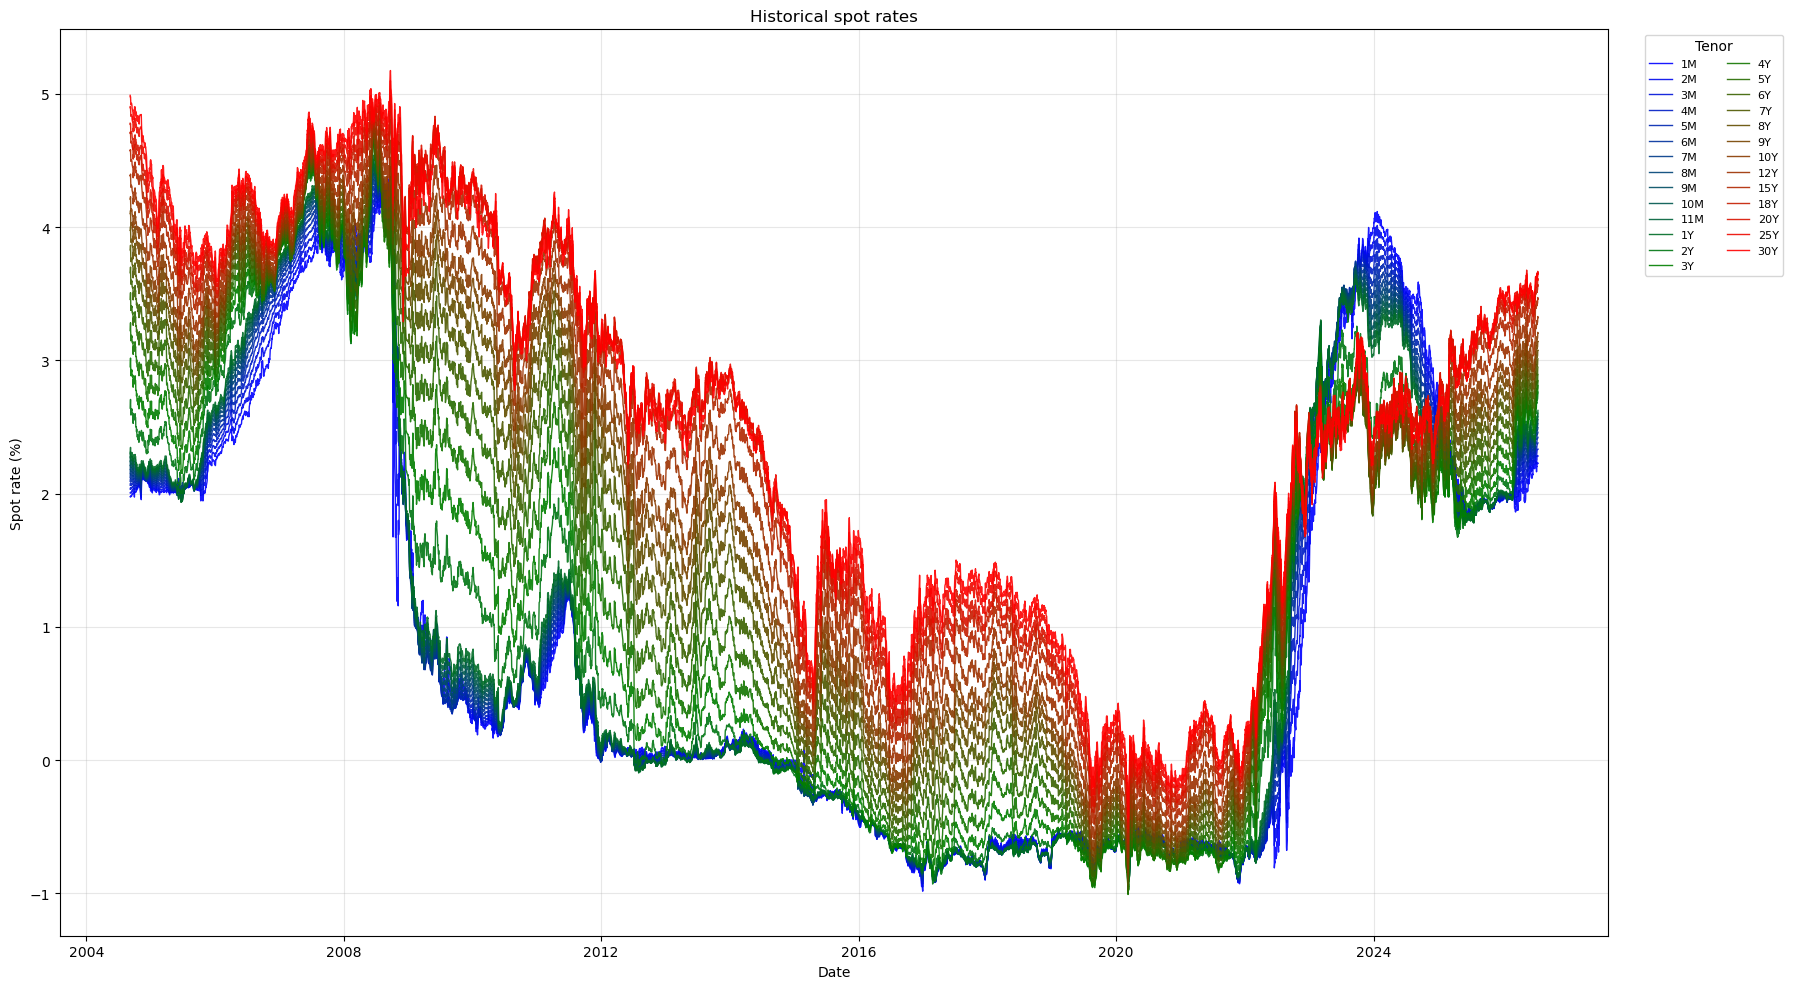

In [6]:
# ------------------------------
# Prepare data.
# ------------------------------
curve["Date"] = pd.to_datetime(curve["Date"])
curve = curve.sort_values("Date")

tenor_columns = [col for col in curve.columns if col != "Date"]

# Ensure numeric values
curve[tenor_columns] = curve[tenor_columns].apply(pd.to_numeric, errors="coerce")

# Sort tenors by maturity
tenor_order = sorted(tenor_columns, key=tenor_to_months)

# ------------------------------
# Custom chromatic scale:
# short tenors = blue
# mid tenors   = green
# long tenors  = red
# ------------------------------
cmap = mcolors.LinearSegmentedColormap.from_list(
    "tenor_scale",
    ["blue", "green", "red"]
)

colors = [cmap(i) for i in np.linspace(0, 1, len(tenor_order))]

# ------------------------------
# Plot
# ------------------------------
plt.figure(figsize=(18, 10))

for tenor, color in zip(tenor_order, colors):
    plt.plot(
        curve["Date"],
        curve[tenor],
        label=tenor,
        color=color,
        linewidth=1.0,
        alpha=0.9
    )

plt.title("Historical spot rates")
plt.xlabel("Date")
plt.ylabel("Spot rate (%)")
plt.grid(True, alpha=0.3)

plt.legend(
    title="Tenor",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    ncol=2,
    fontsize=8
)

plt.tight_layout()
plt.show()

### Historical evolution of spot rates

Following the 2008 financial crisis, Euro area spot rates entered a prolonged period of decline. The overall level of interest rates decreased significantly, while the yield curve generally maintained an upward-sloping shape, reflecting higher rates at longer maturities compared with shorter maturities. This low-rate environment persisted for several years and reached its lowest levels during the COVID-19 period, with extremely loose monetary policy supporting the severe economic shocks caused by government-mandated lockdowns and business closures.

From 2022 onward, inflationary pressures triggered a clear regime shift. Monetary policy tightening led to a sharp increase in short-term rates and a significant repricing across the entire yield curve. During 2023–2024, the curve became inverted, with short maturities exceeding longer maturities.

In 2025, the curve started to normalize gradually. Short-term rates declined from their peak, while longer-term rates remained comparatively elevated. As a result, the yield curve moved back toward an upward-sloping shape, although the overall level of rates remained substantially higher than in the pre-COVID period.

# Term structure shifts
In the present setting the IRRBB shock scenarios are defined as the historically observed shifts of the yield curve at an extreme quantile level (1% or 0.1%).

The shift in rate $r_t(m)$ of tenor $m$ at any given time $t$ is defined as: 

$$
\Delta r_t(m) = r_t(m) - r_{t-k}(m)
$$

Where $k$ is the differentiation term (daily, weekly, monthly, quarterly, yearly).

$\Delta r_t(m)$ is defined over an overlapping intervals given a non-parametric nature of the model. The dataset contains 5592 daily observations (approx. 22 years). A yearly non-overlapping interval will produce 21 observations, which are stastically insignificant for any common sigificance level of a non-parametric quantile approach. 1% quantile requires at least 100 observations, while the 0.1% quantile requires 1000 observations. Instead, a yearly overlapping interval produces 5333 observations.

In [7]:
PERIOD_OFFSETS = {
    "D": pd.DateOffset(days=1),
    "W": pd.DateOffset(weeks=1),
    "M": pd.DateOffset(months=1),
    "Q": pd.DateOffset(months=3),
    "S": pd.DateOffset(months=6),
    "Y": pd.DateOffset(years=1),
}

In [8]:
def compute_difference(
    df: pd.DataFrame, period: str = "Y", date_col: str = "Date"
) -> pd.DataFrame:
    """
    For every date and every tenor column, compute:
        value(date) - value(closest available date on or before date - <period>)
 
    `period` (case-insensitive) is one of:
        "D" - daily difference     (date - 1 day)
        "W" - weekly difference    (date - 1 week)
        "M" - monthly difference   (date - 1 month)
        "Q" - quarterly difference (date - 3 months)
        "S" - half year difference (date - 6 months)
        "Y" - yearly difference    (date - 1 year)
 
    Expects `df` to have a 'Date' column.
    """
    period = period.upper()
    if period not in PERIOD_OFFSETS:
        raise ValueError(
            f"Unknown period '{period}'. Must be one of {list(PERIOD_OFFSETS)}."
        )
    offset = PERIOD_OFFSETS[period]
 
    df = df.sort_values(date_col).reset_index(drop=True)
    dates = pd.DatetimeIndex(pd.to_datetime(df[date_col]))
    target_dates = dates - offset
 
    # position of the last available date <= target_date, for every row
    positions = dates.searchsorted(target_dates, side="right") - 1
    valid = positions >= 0  # False where there's no prior data far enough back
 
    value_cols = [c for c in df.columns if c != date_col]
    diff = pd.DataFrame(index=df.index, columns=value_cols, dtype=float)
    diff.loc[valid, value_cols] = (
        df.loc[valid, value_cols].values - df.iloc[positions[valid]][value_cols].values
    )
 
    return pd.concat([df[[date_col]], diff], axis=1)

In [9]:
diff_df = compute_difference(curve, period=DIFF_PERIOD)
diff_df = diff_df.dropna().reset_index(drop=True)
diff_df

,Date,1M,2M,3M,4M,5M,6M,7M,8M,9M,...,7Y,8Y,9Y,10Y,12Y,15Y,18Y,20Y,25Y,30Y
0,2005-09-06,0.058550,0.026597,-0.004666,-0.035238,-0.065122,-0.094323,-0.122845,-0.150694,-0.177877,...,-1.024800,-1.058410,-1.083902,-1.103979,-1.134358,-1.167384,-1.192889,-1.207163,-1.235655,-1.256385
1,2005-09-07,0.062962,0.026765,-0.008368,-0.042465,-0.075551,-0.107652,-0.138792,-0.168998,-0.198293,...,-1.026451,-1.055874,-1.078119,-1.095695,-1.122660,-1.152901,-1.176977,-1.190661,-1.218257,-1.238471
2,2005-09-08,0.070739,0.031475,-0.006562,-0.043407,-0.079094,-0.113657,-0.147127,-0.179536,-0.210916,...,-1.067193,-1.094726,-1.114948,-1.130488,-1.153589,-1.178895,-1.199107,-1.210718,-1.234430,-1.252002
3,2005-09-09,0.068503,0.035361,0.003066,-0.028396,-0.059040,-0.088881,-0.117935,-0.146216,-0.173740,...,-1.007404,-1.040513,-1.065717,-1.085611,-1.115737,-1.148434,-1.173668,-1.187812,-1.216143,-1.236851
4,2005-09-12,0.051530,0.027804,0.004337,-0.018850,-0.041742,-0.064323,-0.086579,-0.108501,-0.130077,...,-0.899186,-0.935124,-0.962724,-0.984556,-1.017371,-1.052136,-1.078250,-1.092686,-1.121368,-1.142249
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5328,2026-07-16,0.320258,0.388187,0.449410,0.504477,0.553892,0.598122,0.637598,0.672714,0.703837,...,0.527830,0.485578,0.453865,0.430726,0.403836,0.395313,0.408166,0.422967,0.468152,0.512785
5329,2026-07-17,0.386537,0.446861,0.501248,0.550178,0.594095,0.633407,0.668491,0.699696,0.727341,...,0.525849,0.479413,0.443194,0.415555,0.380431,0.362494,0.369374,0.381721,0.424436,0.469788
5330,2026-07-20,0.385601,0.447965,0.503966,0.554138,0.598972,0.638919,0.674395,0.705780,0.733426,...,0.515487,0.470934,0.436618,0.410805,0.378974,0.365067,0.375076,0.389110,0.434971,0.482307
5331,2026-07-21,0.380847,0.444775,0.502657,0.554979,0.602191,0.644706,0.682907,0.717145,0.747744,...,0.640041,0.595755,0.560508,0.533160,0.497838,0.479886,0.487936,0.501513,0.547455,0.594691


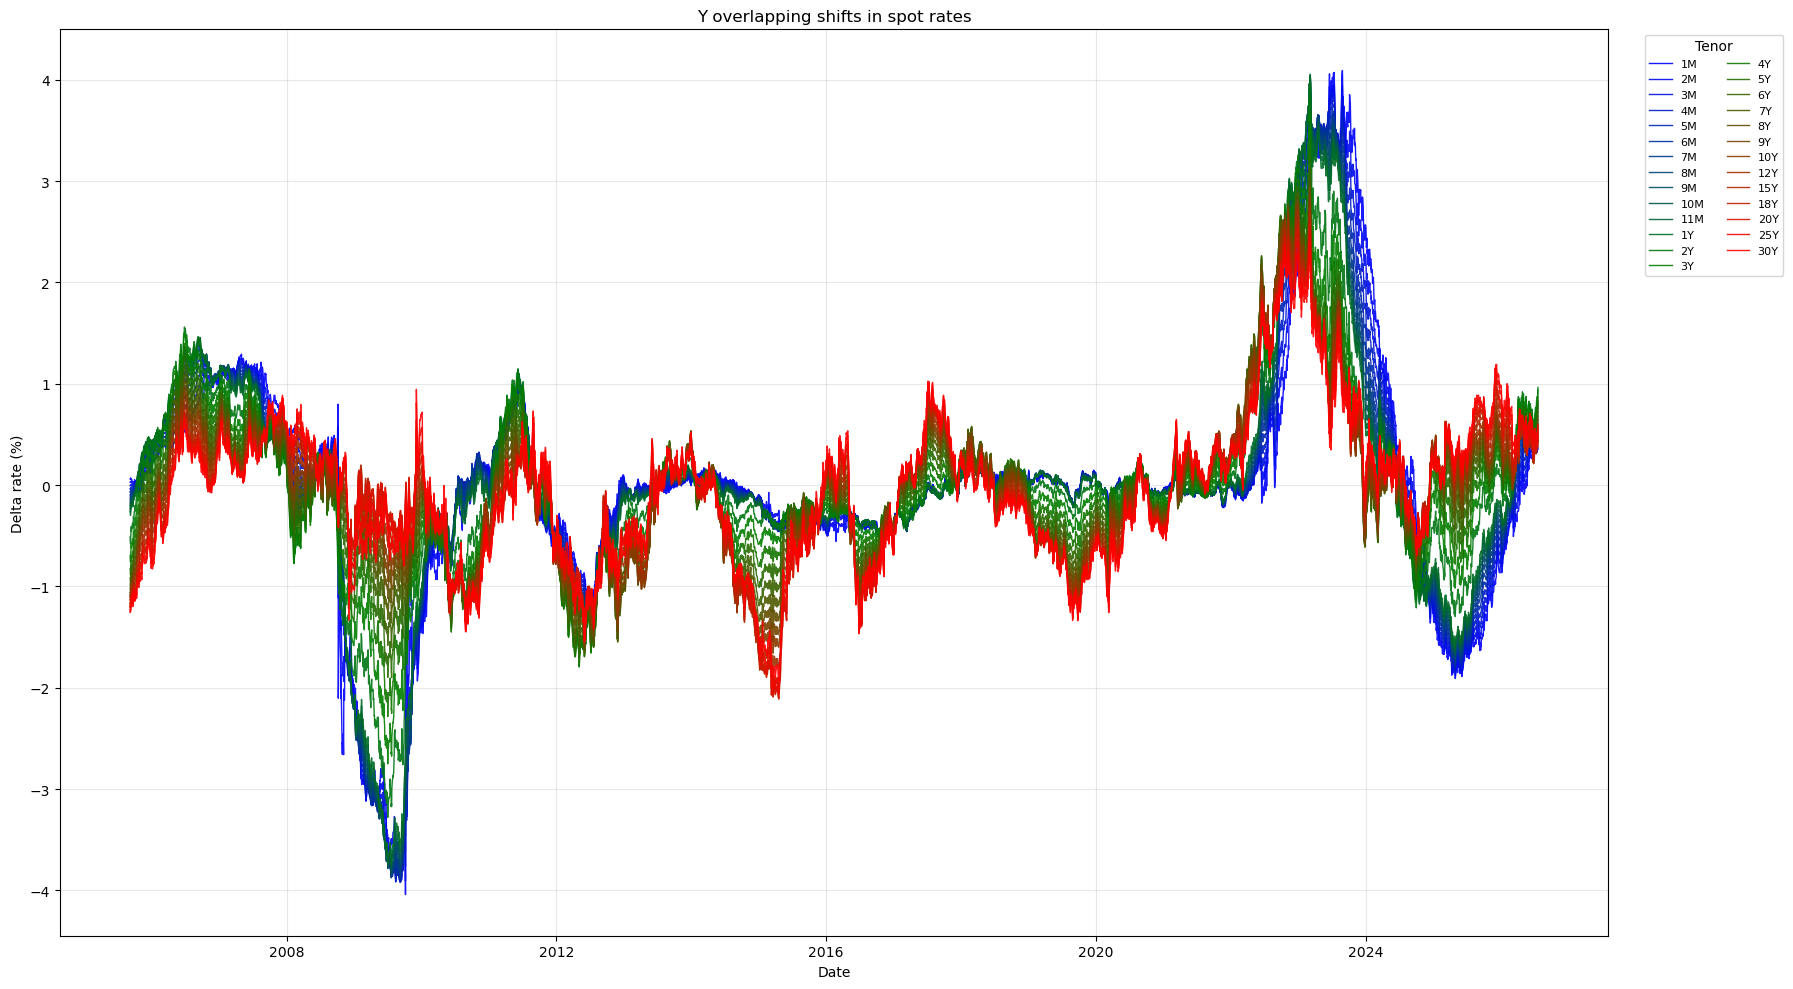

In [10]:
# ------------------------------
# Plot.
# ------------------------------
plt.figure(figsize=(18, 10))

for tenor, color in zip(tenor_order, colors):
    plt.plot(
        diff_df["Date"],
        diff_df[tenor],
        label=tenor,
        color=color,
        linewidth=1.0,
        alpha=0.9
    )

plt.title(f"{DIFF_PERIOD} overlapping shifts in spot rates")
plt.xlabel("Date")
plt.ylabel("Delta rate (%)")
plt.grid(True, alpha=0.3)

plt.legend(
    title="Tenor",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    ncol=2,
    fontsize=8
)

plt.tight_layout()
plt.show()

### Changes in the term structure (Y difference)

Two main periods stand out in the evolution of the term structure.

In 2008, the red-blue spread widened, with longer-term rates moving above shorter-term rates. This reflected a steepening of the yield curve, as short-term rates declined and remained consistently below long-term rates.

In 2022–2023, the opposite pattern emerged. Short-term rates rose sharply and moved above long-term rates, leading to a marked flattening and, in some periods, an inversion of the yield curve.

This pattern is consistent with the transmission of monetary policy, which primarily affects short-term rates. As a result, short maturities display higher volatility than long maturities. The magnitude of short-term shocks is approximately $\pm 4\%$, while for longer maturities it is closer to $\pm 2.5\%$.

# PCA

The original term structure contains 27 maturity points. Principal Component Analysis (PCA) provides a significant dimensionality reduction, as a small number of components is sufficient to explain most of the variation in the curve.

In practice, the first three Principal Components (PCs) typically explain more than 99% of the total variance of the term structure and have a clear economic interpretation:

- **First principal component:** parallel shifts of the yield curve, commonly interpreted as the **level** factor.
- **Second principal component:** changes in the slope of the curve, corresponding to **steepening** or **flattening** movements.
- **Third principal component:** changes in the curvature of the curve, corresponding to **butterfly** or **inverse-butterfly** movements.

As the number of PCs increases, so do the explained variance. When the number of PCs is equal to the number of features (27 maturity points), the explained variance is 100%.

Although PCA can be performed on any kind of term curve (level, shifts, relative shifts), it is recommended to do so on changes in rates rather than on the level of the yield curve. This allows the analysis to focus on movements in the term structure rather than on the absolute level of rates.

PCA is sensible to scaling. If features are measured in different units that are not comparable, PCA will bias towards a factor with higher absolute variance. Therefore the standardization of the features will be required. In practice if the features are in the same measurement unit, the original scale can be preserved and only de-meaning of the series will be performed.

In [11]:
# --------------------------------------------------------------------------
# De-mean the shifts.
# --------------------------------------------------------------------------
 
 
def standardize(df: pd.DataFrame, date_col: str = "Date") -> pd.DataFrame:
    """
    De-mean each tenor column:
    (value - mean)
 
    Mean and std are computed per column over all rows of `df` (sample std,
    ddof=1). Keeps 'Date' as a regular column.
    Expects `df` to have a 'Date' column.    
    """
    value_cols = [c for c in df.columns if c != date_col]
    means = df[value_cols].mean()
    #stds = df[value_cols].std()
    #z = (df[value_cols] - means) / stds
    z = (df[value_cols] - means)
    return pd.concat([df[[date_col]], z], axis=1)
 
 
standardized_diff_df = standardize(diff_df)

In [12]:
# --------------------------------------------------------------------------
# PCA on the standardized shifts.
# --------------------------------------------------------------------------

N_COMPONENTS = 3  # <-- choose the number of principal components you want

def compute_pca(df: pd.DataFrame, n_components: int, date_col: str = "Date"):
    """
    Run PCA on the tenor columns of `df` (expected to already be standardized:
    de-meaned, unit variance).
    Expects `df` to have a 'Date' column.
 
    Returns:
      pca          : the fitted sklearn PCA object
      scores_df    : 'Date' + PC1..PCn scores (the transformed / projected data)
      explained_df : table with explained variance ratio and cumulative
                     variance explained, per principal component
      loadings_df  : PCA loadings (components), rows = PCs, columns = tenors
    """
    value_cols = [c for c in df.columns if c != date_col]
    n_components = min(n_components, len(value_cols))  # can't exceed n° of tenors
 
    X = df[value_cols].values
 
    pca = PCA(n_components=n_components)
    scores = pca.fit_transform(X)
 
    pc_names = [f"PC{i + 1}" for i in range(n_components)]
 
    scores_df = pd.concat(
        [df[[date_col]].reset_index(drop=True), pd.DataFrame(scores, columns=pc_names)],
        axis=1,
    )
 
    explained_df = pd.DataFrame({
        "Principal Component": pc_names,
        "Explained Variance Ratio": pca.explained_variance_ratio_,
        "Cumulative Variance Explained": np.cumsum(pca.explained_variance_ratio_),
    })
 
    loadings_df = pd.DataFrame(pca.components_, index=pc_names, columns=value_cols)
 
    return pca, scores_df, explained_df, loadings_df
 
 
pca_model, pca_scores_df, pca_explained_df, pca_loadings_df = compute_pca(
    standardized_diff_df, n_components=N_COMPONENTS
)

In [13]:
PERIOD_LABELS = {
    "D": "daily",
    "W": "weekly",
    "M": "monthly",
    "Q": "quarterly",
    "S": "semestral",
    "Y": "yearly",
}

print()
print(f"PCA on standardized {PERIOD_LABELS[DIFF_PERIOD]} shifts "
      f"({pca_loadings_df.shape[0]} components, {pca_loadings_df.shape[1]} tenors):")
print(pca_explained_df.to_string(index=False))


PCA on standardized yearly shifts (3 components, 27 tenors):
Principal Component  Explained Variance Ratio  Cumulative Variance Explained
                PC1                  0.832045                       0.832045
                PC2                  0.146430                       0.978475
                PC3                  0.016119                       0.994594


In [14]:
pca_scores_df #principal components scores

,Date,PC1,PC2,PC3
0,2005-09-06,-2.245341,-3.268316,-0.117276
1,2005-09-07,-2.290013,-3.231304,-0.056600
2,2005-09-08,-2.376832,-3.320586,-0.008315
3,2005-09-09,-2.196973,-3.221910,-0.104542
4,2005-09-12,-1.912234,-2.929830,-0.186800
...,...,...,...,...
5328,2026-07-16,2.951374,0.763522,-0.505192
5329,2026-07-17,3.030456,0.630368,-0.504216
5330,2026-07-20,3.035053,0.620040,-0.482970
5331,2026-07-21,3.279272,0.980682,-0.506215


In [15]:
pca_loadings_df #eigenvectors

,1M,2M,3M,4M,5M,6M,7M,8M,9M,10M,...,7Y,8Y,9Y,10Y,12Y,15Y,18Y,20Y,25Y,30Y
PC1,0.234899,0.240534,0.244243,0.246452,0.247492,0.247623,0.247050,0.245933,0.244400,0.242550,...,0.137386,0.131197,0.126198,0.122133,0.116105,0.110633,0.107793,0.106807,0.106152,0.106805
PC2,-0.194907,-0.184995,-0.174307,-0.163202,-0.151936,-0.140688,-0.129576,-0.118678,-0.108045,-0.097706,...,0.217410,0.233142,0.245164,0.254368,0.266738,0.275684,0.277951,0.277225,0.270994,0.261646
PC3,0.381098,0.287165,0.206708,0.137533,0.077865,0.026240,-0.018548,-0.057502,-0.091458,-0.121115,...,-0.122788,-0.070130,-0.021255,0.023024,0.096962,0.174024,0.218791,0.235473,0.247597,0.236280


## PCA estimation

Strictly speaking, there is no "estimation" in the PCA analysis as it is commonly understood in the econometrical statistics. PCA is primarily a descriptive dimensionality reduction technique rather than a conventional econometric model estimated through regression or likelihood methods. PCA reduces the dimensionality of an $n$ dataset by projecting it onto the $k$ (with $k<n$) orthogonal directions that capture the greatest amount of variance. All of the original features in dimension $n$ can be approximately reconstructed by just $k$ PCs. As $k$ increases the approximation improves, and for $k=n$ the reconstructed features will perfectly match the original dataset.

The PCA orthogonal projection $\widetilde{\Delta} r_t(m)$ is given by: 

$$
\widetilde{\Delta} r_t(m) ≈ \sum_{k=1}^{k<n} PC_k(t) \cdot w_k(m) + \epsilon
$$

Where:
- $PC_k$ is the $k$-th Principal Component score at time $t$
- $w_k(m)$ is the $k$-th eigenvector (loading factor) of tenor $m$
- $\epsilon$ is the reconstruction error

In [16]:
# --------------------------------------------------------------------------
# Re-compute (reconstruct) the yield shifts from the PCA scores + loadings.
# --------------------------------------------------------------------------
 
def reconstruct_from_pca(
    scores_df: pd.DataFrame,
    loadings_df: pd.DataFrame,
    means: pd.Series,
    stds: pd.Series,
    date_col: str = "Date",
) -> pd.DataFrame:
    """
    Re-compute the yield shifts, for every tenor and every date, using only
    the retained principal components:
 
        standardized_reconstruction = scores @ loadings
        reconstructed_shift          = standardized_reconstruction * std + mean
 
    (the last step undoes the earlier de-mean/standardize step, so the
    result is back in the same units as `diff_df`, e.g. percentage points).
 
    `means` / `stds` must be the same per-tenor mean/std used to build
    `standardized_diff_df` in the first place (see `standardize()`).
    """
    pc_cols = [c for c in scores_df.columns if c != date_col]
    tenor_cols = loadings_df.columns.tolist()
 
    scores_matrix = scores_df[pc_cols].values      # (n_dates, n_components)
    loadings_matrix = loadings_df.values           # (n_components, n_tenors)
 
    recon_z = scores_matrix @ loadings_matrix      # standardized units
    #recon = recon_z * stds[tenor_cols].values + means[tenor_cols].values
    recon = recon_z + means[tenor_cols].values
 
    recon_df = pd.DataFrame(recon, columns=tenor_cols)
    recon_df.insert(0, date_col, scores_df[date_col].values)
    return recon_df

In [17]:
# same per-tenor mean/std that were used inside standardize(diff_df) earlier
_value_cols = [c for c in diff_df.columns if c != "Date"]
_diff_means = diff_df[_value_cols].mean()
_diff_stds = diff_df[_value_cols].std()
 
reconstructed_diff_df = reconstruct_from_pca(
    pca_scores_df, pca_loadings_df, _diff_means, _diff_stds
)
 
# how good is the reconstruction with only N_COMPONENTS PCs? (RMSE per tenor,
# in the same units as the original shifts)
reconstruction_error = diff_df.set_index("Date")[_value_cols] - reconstructed_diff_df.set_index("Date")[_value_cols]
reconstruction_rmse = np.sqrt((reconstruction_error ** 2).mean())
 
print()
print(f"Reconstructed {PERIOD_LABELS[DIFF_PERIOD]} shifts using {N_COMPONENTS} "
      f"principal component(s). Reconstruction RMSE per tenor "
      f"(0 = perfect, larger = more information lost by using only "
      f"{N_COMPONENTS} PC(s)):")
print(reconstruction_rmse.to_string())


Reconstructed yearly shifts using 3 principal component(s). Reconstruction RMSE per tenor (0 = perfect, larger = more information lost by using only 3 PC(s)):
1M     0.159324
2M     0.083203
3M     0.041110
4M     0.033222
5M     0.042075
6M     0.050116
7M     0.055021
8M     0.057635
9M     0.058941
10M    0.059653
11M    0.060204
1Y     0.060813
2Y     0.070772
3Y     0.071799
4Y     0.069260
5Y     0.066865
6Y     0.064990
7Y     0.062940
8Y     0.060185
9Y     0.056691
10Y    0.052816
12Y    0.046182
15Y    0.044654
18Y    0.050964
20Y    0.056917
25Y    0.080399
30Y    0.121586


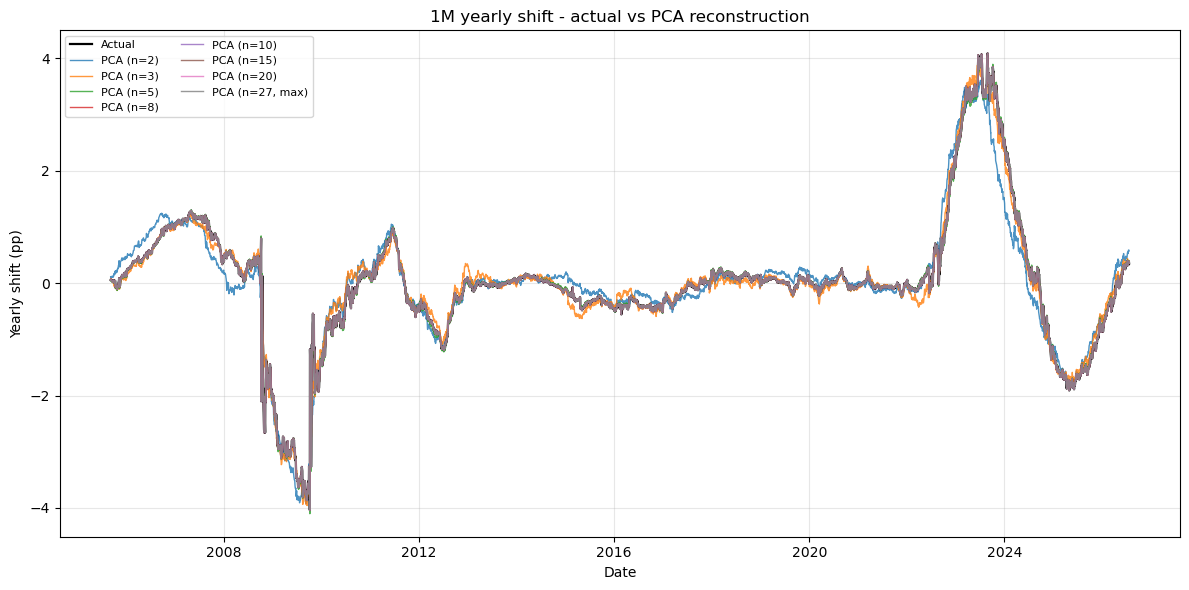

In [18]:
# --------------------------------------------------------------------------
# Plot: one selected tenor, actual vs PCA reconstruction with varying n.
# --------------------------------------------------------------------------
 
PLOT_TENOR = "1M"  # <-- change this to whichever tenor column you want to inspect


PLOT_N_COMPONENTS_LIST = [2, 3, 5, 8, 10, 15, 20]  # the "maximum theoretical" is added automatically
 
if PLOT_TENOR not in diff_df.columns:
    available = [c for c in diff_df.columns if c != "Date"]
    raise ValueError(f"'{PLOT_TENOR}' is not a valid tenor column. Available: {available}")
 
_all_tenor_cols = [c for c in standardized_diff_df.columns if c != "Date"]
_max_components = len(_all_tenor_cols)  # theoretical max = number of tenors available
 
# Fit PCA once with the maximum possible number of components. Reconstructions
# using fewer components are simply truncations of this same fit (sklearn's
# PCA components are nested / ordered by decreasing explained variance, so
# this gives identical results to refitting PCA(n_components=n) separately
# for each n, without redoing the SVD every time).

_, _scores_full, _, _loadings_full = compute_pca(
    standardized_diff_df, n_components=_max_components
)
 
# de-duplicate + clip requested component counts to the theoretical max, and
# always include the max itself as the final comparison line
plot_n_list = sorted(set(n for n in PLOT_N_COMPONENTS_LIST if n <= _max_components) | {_max_components})
 
 
def _pc_label(n: int) -> str:
    return f"PCA (n={n})" if n < _max_components else f"PCA (n={n}, max)"
 
 
plot_df = diff_df[["Date", PLOT_TENOR]].rename(columns={PLOT_TENOR: "Actual"}).copy()
 
for n in plot_n_list:
    pc_cols_n = [f"PC{i + 1}" for i in range(n)]
    scores_n = _scores_full[["Date"] + pc_cols_n]
    loadings_n = _loadings_full.iloc[:n]
    recon_n = reconstruct_from_pca(scores_n, loadings_n, _diff_means, _diff_stds)
    plot_df[_pc_label(n)] = recon_n[PLOT_TENOR].values
 
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(plot_df["Date"], plot_df["Actual"], label="Actual", color="black", linewidth=1.6)
for n in plot_n_list:
    ax.plot(plot_df["Date"], plot_df[_pc_label(n)], label=_pc_label(n), linewidth=1, alpha=0.8)
 
ax.set_title(f"{PLOT_TENOR} {PERIOD_LABELS[DIFF_PERIOD]} shift - actual vs PCA reconstruction")
ax.set_xlabel("Date")
ax.set_ylabel(f"{PERIOD_LABELS[DIFF_PERIOD].capitalize()} shift (pp)")
ax.legend(loc="best", fontsize=8, ncol=2)
ax.grid(alpha=0.3)
fig.tight_layout()
 
plt.show()

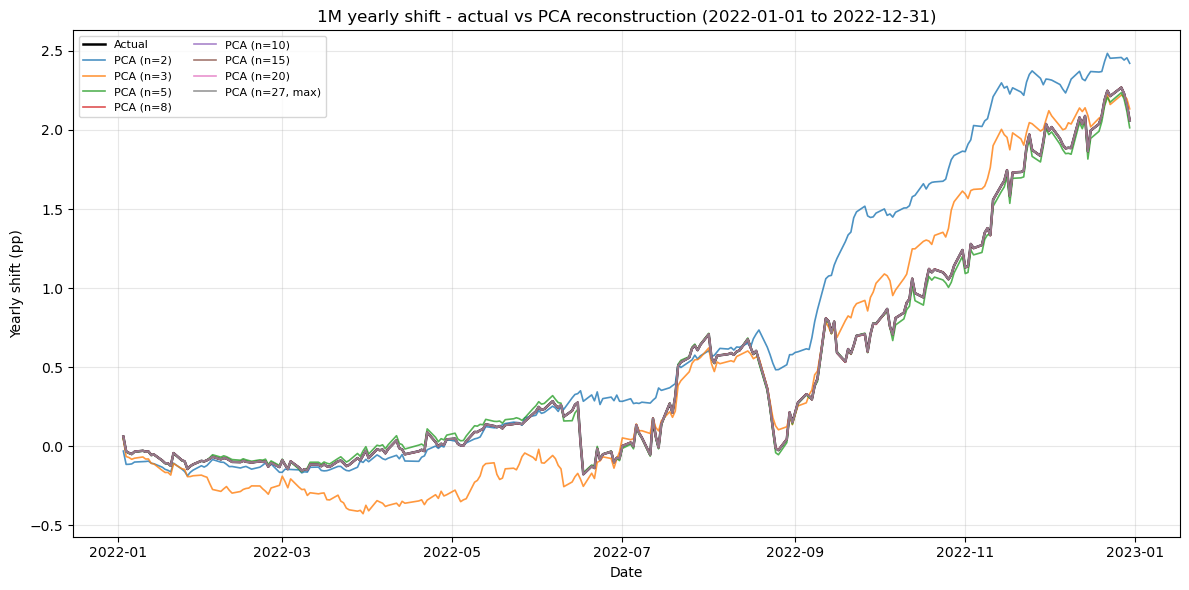

In [19]:
# --------------------------------------------------------------------------
# Zoom in to a specific date window.
# --------------------------------------------------------------------------
 
ZOOM_START = "2022-01-01"  # <-- change these two to whatever window you want
ZOOM_END = "2022-12-31"    # <-- change these two to whatever window you want
 
zoom_mask = (plot_df["Date"] >= ZOOM_START) & (plot_df["Date"] <= ZOOM_END)
zoom_df = plot_df.loc[zoom_mask]
 
if zoom_df.empty:
    print(f"\nWARNING: no data between {ZOOM_START} and {ZOOM_END} -- skipping zoomed plot.")
else:
    fig_zoom, ax_zoom = plt.subplots(figsize=(12, 6))
    ax_zoom.plot(zoom_df["Date"], zoom_df["Actual"], label="Actual", color="black", linewidth=1.8)
    for n in plot_n_list:
        ax_zoom.plot(zoom_df["Date"], zoom_df[_pc_label(n)], label=_pc_label(n), linewidth=1.2, alpha=0.8)
 
    ax_zoom.set_title(
        f"{PLOT_TENOR} {PERIOD_LABELS[DIFF_PERIOD]} shift - actual vs PCA reconstruction "
        f"({ZOOM_START} to {ZOOM_END})"
    )
    ax_zoom.set_xlabel("Date")
    ax_zoom.set_ylabel(f"{PERIOD_LABELS[DIFF_PERIOD].capitalize()} shift (pp)")
    ax_zoom.legend(loc="best", fontsize=8, ncol=2)
    ax_zoom.grid(alpha=0.3)
    fig_zoom.tight_layout()
    plt.show()

## Principal Components

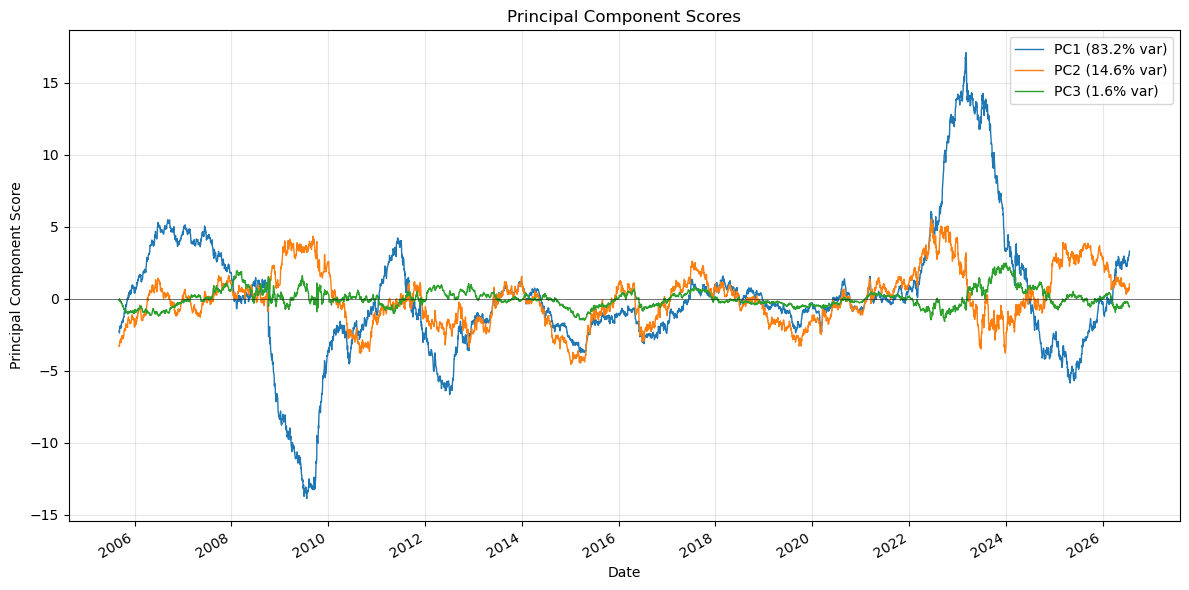

In [20]:
# --------------------------------------------------------------------------
# Plot Principal Components scores.
# --------------------------------------------------------------------------
 
pc_score_cols = [
    c for c in pca_scores_df.columns
    if c != "Date"
]  # PC1..PCn

fig_pc, ax_pc = plt.subplots(figsize=(12, 6))

for pc in pc_score_cols:
    var_pct = pca_explained_df.loc[
        pca_explained_df["Principal Component"] == pc,
        "Explained Variance Ratio"
    ].iloc[0] * 100

    ax_pc.plot(
        pca_scores_df["Date"],
        pca_scores_df[pc],
        linewidth=1,
        label=f"{pc} ({var_pct:.1f}% var)"
    )

ax_pc.axhline(
    0,
    color="black",
    linewidth=0.7,
    alpha=0.5
)

ax_pc.set_xlabel("Date")
ax_pc.set_ylabel("Principal Component Score")
ax_pc.set_title("Principal Component Scores")

ax_pc.xaxis.set_major_locator(
    mdates.YearLocator(base=2)
)
ax_pc.xaxis.set_major_formatter(
    mdates.DateFormatter("%Y")
)

ax_pc.grid(alpha=0.3)
ax_pc.legend()

fig_pc.autofmt_xdate()
plt.tight_layout()
plt.show()

###
PC1 captures the main common movement across maturities interpreted as a parallel upward or downward shift of the yield curve. Periods when the PC1 is highly positive (negative) correspond to a significant upward (downward) move of the term structure. 
During the 2008-2009 financial crysis, the PC1 is negative and PC2 is highly positive. This combination describes a parallel down scenario with a steepening component. An opposite situation can be observed during the 2022-2023 monetary tightening shock. PC1 is highly positive and PC2 is negative, which describe an upward move in the yield curve paired with flattening (even inverted) component. A partial restore to an upward term structure can be observed during 2025 with the reduction in the level of the rates (negative PC1) paired with the de-inversion of the slope (positive PC2).

**Technical note:** 
The PCA performed with R software (find "PCA.R" in the repository) will produce PC scores and eigenvectors with an opposite sign. This behaviour is expected as the PCA defines the axis and not the direction along that axis. The opposite signs indicate a switching axes from a geometrical point of view, but with exactly the same economical meaning. Additional thread on this topic: https://stackoverflow.com/questions/60298737/difference-between-pca-done-in-r-and-python#:~:text=The%20difference%20is%20the%20sign,whereas%20intercept%20is%20the%20same).

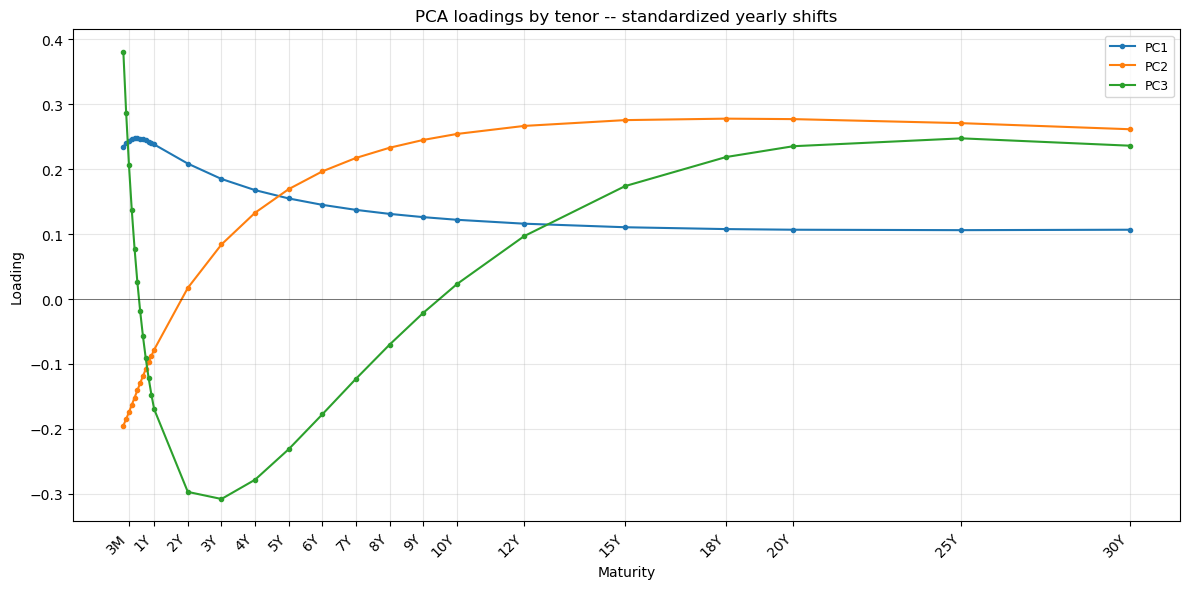

In [21]:
# --------------------------------------------------------------------------
# Plot eigenvectors.
# --------------------------------------------------------------------------

def _tenor_to_years(t: str) -> float:
    """Convert a tenor label like '3M' or '10Y' into a maturity in years."""
    return int(t[:-1]) / 12 if t.endswith("M") else int(t[:-1])
 
 
_tenor_cols_sorted = sorted(pca_loadings_df.columns, key=_tenor_to_years)
_maturities_years = [_tenor_to_years(t) for t in _tenor_cols_sorted]
 
fig_load, ax_load = plt.subplots(figsize=(12, 6))
for pc in pca_loadings_df.index:
    ax_load.plot(
        _maturities_years,
        pca_loadings_df.loc[pc, _tenor_cols_sorted].values,
        marker="o",
        markersize=3,
        linewidth=1.5,
        label=pc,
    )
 
ax_load.axhline(0, color="black", linewidth=0.7, alpha=0.5)
ax_load.set_xlabel("Maturity")
ax_load.set_ylabel("Loading")
ax_load.set_title(f"PCA loadings by tenor -- standardized {PERIOD_LABELS[DIFF_PERIOD]} shifts")
 
# Only label a sparser subset of ticks: the sub-1Y tenors (1M..11M) sit very
# close together in actual maturity-year terms, so labeling every one of
# them overlaps illegibly. Keep only 3M plus every full-year tenor.
_labelled_tenors = {"3M"} | {t for t in _tenor_cols_sorted if t.endswith("Y")}
_label_positions = [
    m for t, m in zip(_tenor_cols_sorted, _maturities_years) if t in _labelled_tenors
]
_label_names = [t for t in _tenor_cols_sorted if t in _labelled_tenors]
 
ax_load.set_xticks(_label_positions)
ax_load.set_xticklabels(_label_names, rotation=45, ha="right")
ax_load.legend(loc="best", fontsize=9)
ax_load.grid(alpha=0.3)
fig_load.tight_layout()
 

###
The economic interpretation of the eigenvectors is the same as of the PCs.
- **First principal component:** is almost flat and takes positive values indicating parallel shifts in the yield curve.
- **Second principal component:** have a concave shape indicating changes in the slope of the curve, corresponding to steepening or flattening movements.
- **Third principal component:** indicates changes in the curvature of the curve, corresponding to butterfly (positive shifts in short/long term rates, paired with negative move of mid term rates) or inverse-butterfly movements.

**Technical note:** 
Same comment as per PC score ceil applies in this eigenvector ceil.

# Shock model
Shock scenarios are defined as the term-structure shifts associated with the 99.9th and 0.1st percentiles of the score distribution of any of the first three principal components (PC1, PC2 and PC3).

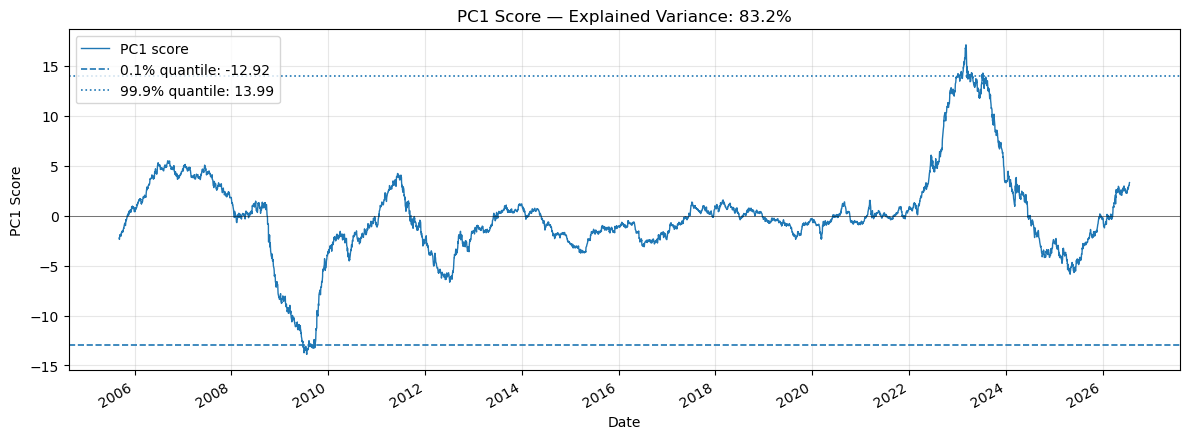

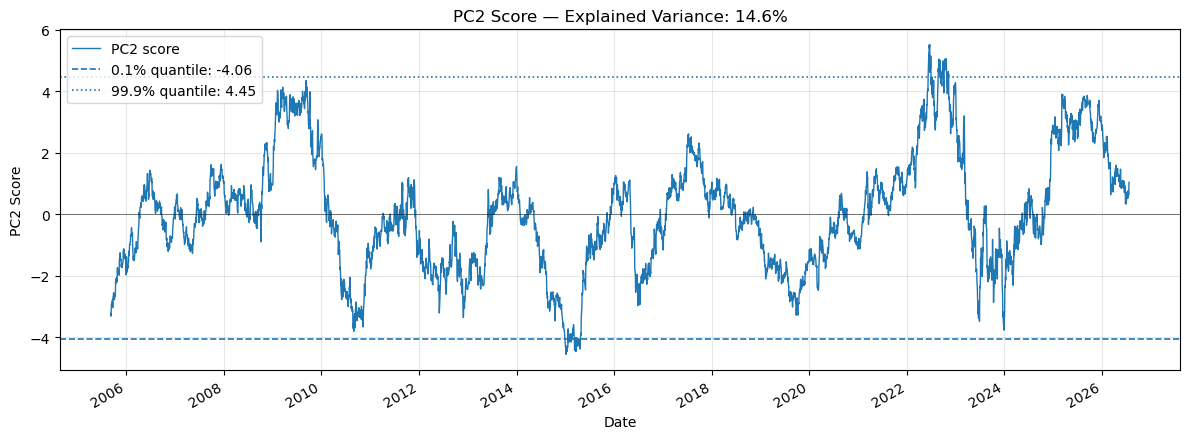

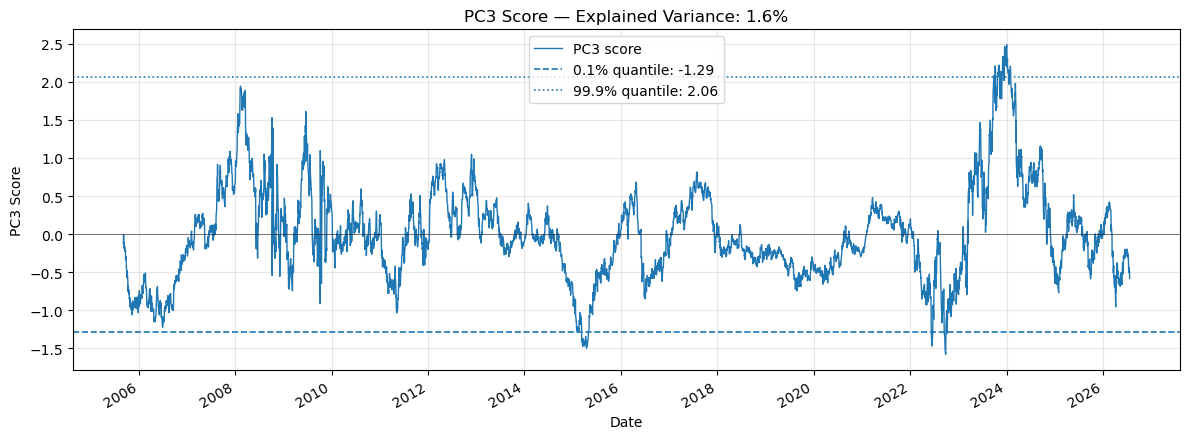

In [22]:
# --------------------------------------------------------------------------
# Plot quantiles.
# --------------------------------------------------------------------------

pc_score_cols = [
    c for c in pca_scores_df.columns
    if c != "Date"
]

for pc in pc_score_cols:

    plotted_scores = pca_scores_df[pc]

    # Empirical 0.1% and 99.9% quantiles
    q_001 = plotted_scores.quantile(0.01)
    q_999 = plotted_scores.quantile(0.99)

    var_pct = pca_explained_df.loc[
        pca_explained_df["Principal Component"] == pc,
        "Explained Variance Ratio"
    ].iloc[0] * 100

    # One separate figure for each PC
    fig, ax = plt.subplots(figsize=(12, 4.5))

    score_line, = ax.plot(
        pca_scores_df["Date"],
        plotted_scores,
        linewidth=1,
        label=f"{pc} score"
    )

    pc_colour = score_line.get_color()

    # Zero line
    ax.axhline(
        0,
        color="black",
        linewidth=0.7,
        alpha=0.5
    )

    # Lower quantile
    ax.axhline(
        q_001,
        color=pc_colour,
        linestyle="--",
        linewidth=1.2,
        label=f"0.1% quantile: {q_001:.2f}"
    )

    # Upper quantile
    ax.axhline(
        q_999,
        color=pc_colour,
        linestyle=":",
        linewidth=1.2,
        label=f"99.9% quantile: {q_999:.2f}"
    )

    ax.set_title(
        f"{pc} Score — Explained Variance: {var_pct:.1f}%"
    )
    ax.set_xlabel("Date")
    ax.set_ylabel(f"{pc} Score")

    ax.xaxis.set_major_locator(
        mdates.YearLocator(base=2)
    )
    ax.xaxis.set_major_formatter(
        mdates.DateFormatter("%Y")
    )

    ax.grid(alpha=0.3)
    ax.legend(loc="best")

    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

In [23]:
# --------------------------------------------------------------------------
# Identify dates triggering quantiles limits.
# --------------------------------------------------------------------------

extreme_dates_list = []

for pc in pc_score_cols:

    # Keep this sign reversal if it was also used in the plots
    scores = pca_scores_df[pc]

    q_001 = scores.quantile(0.001)
    q_999 = scores.quantile(0.999)

    extreme_mask = (
        (scores <= q_001) |
        (scores >= q_999)
    )

    pc_extremes = pca_scores_df.loc[
        extreme_mask, ["Date"]
    ].copy()

    pc_extremes["Principal Component"] = pc
    pc_extremes["Score"] = scores.loc[extreme_mask]

    pc_extremes["Tail"] = np.where(
        pc_extremes["Score"] >= q_999,
        "Above 99.9% quantile",
        "Below 0.1% quantile"
    )

    pc_extremes["Quantile threshold"] = np.where(
        pc_extremes["Score"] >= q_999,
        q_999,
        q_001
    )

    extreme_dates_list.append(pc_extremes)

extreme_dates_df = (
    pd.concat(extreme_dates_list, ignore_index=True)
      .sort_values(["Principal Component", "Date"])
      .reset_index(drop=True)
)

extreme_dates_df

,Date,Principal Component,Score,Tail,Quantile threshold
0,2009-07-02,PC1,-13.734238,Below 0.1% quantile,-13.530140
1,2009-07-20,PC1,-13.545323,Below 0.1% quantile,-13.530140
2,2009-07-21,PC1,-13.835924,Below 0.1% quantile,-13.530140
3,2009-07-22,PC1,-13.843049,Below 0.1% quantile,-13.530140
4,2009-07-23,PC1,-13.890074,Below 0.1% quantile,-13.530140
5,2009-07-24,PC1,-13.553803,Below 0.1% quantile,-13.530140
6,2023-03-01,PC1,16.732966,Above 99.9% quantile,16.631534
7,2023-03-02,PC1,16.801615,Above 99.9% quantile,16.631534
8,2023-03-03,PC1,16.699014,Above 99.9% quantile,16.631534
9,2023-03-06,PC1,17.104728,Above 99.9% quantile,16.631534


In [24]:
# --------------------------------------------------------------------------
# Dates when all 3 PCs are simultaneously triggering quantiles.
# --------------------------------------------------------------------------

plotted_scores_df = pca_scores_df[pc_score_cols]

lower_quantiles = plotted_scores_df.quantile(0.001)
upper_quantiles = plotted_scores_df.quantile(0.999)

all_above_999 = plotted_scores_df.ge(
    upper_quantiles,
    axis="columns"
).all(axis=1)

all_below_001 = plotted_scores_df.le(
    lower_quantiles,
    axis="columns"
).all(axis=1)

simultaneous_extreme_dates = pca_scores_df.loc[
    all_above_999 | all_below_001,
    ["Date"]
].copy()

simultaneous_extreme_dates["Scenario"] = np.where(
    all_above_999.loc[all_above_999 | all_below_001],
    "All PCs above 99.9% quantiles",
    "All PCs below 0.1% quantiles"
)

simultaneous_extreme_dates
#none

,Date,Scenario


In [25]:
# ------------------------------------------------------------------
# Check whether max/min shifts of each tenor are identified by quantile PCA.
# ------------------------------------------------------------------

# ------------------------------------------------------------------
# 1. Prepare the term-structure shift dataframe
# ------------------------------------------------------------------

df_diff_check = diff_df.copy()

df_diff_check["Date"] = (
    pd.to_datetime(df_diff_check["Date"])
      .dt.normalize()
)

tenor_cols = [
    col for col in df_diff_check.columns
    if col != "Date"
]

# Convert from wide to long format
df_diff_long = (
    df_diff_check
    .melt(
        id_vars="Date",
        value_vars=tenor_cols,
        var_name="Tenor",
        value_name="Shift"
    )
    .dropna(subset=["Shift"])
)

# ------------------------------------------------------------------
# 2. Identify the maximum and minimum shift for each tenor
# ------------------------------------------------------------------

max_idx = df_diff_long.groupby("Tenor")["Shift"].idxmax()
min_idx = df_diff_long.groupby("Tenor")["Shift"].idxmin()

maximum_shifts = (
    df_diff_long.loc[max_idx]
    .assign(Scenario="Maximum shift")
)

minimum_shifts = (
    df_diff_long.loc[min_idx]
    .assign(Scenario="Minimum shift")
)

tenor_extremes_df = pd.concat(
    [maximum_shifts, minimum_shifts],
    ignore_index=True
)

# Preserve the original tenor order
tenor_order = {
    tenor: position
    for position, tenor in enumerate(tenor_cols)
}

tenor_extremes_df["Tenor_order"] = (
    tenor_extremes_df["Tenor"].map(tenor_order)
)

scenario_order = pd.CategoricalDtype(
    categories=["Maximum shift", "Minimum shift"],
    ordered=True
)

tenor_extremes_df["Scenario"] = (
    tenor_extremes_df["Scenario"].astype(scenario_order)
)

tenor_extremes_df = (
    tenor_extremes_df
    .sort_values(["Tenor_order", "Scenario"])
    .drop(columns="Tenor_order")
    .reset_index(drop=True)
)

# ------------------------------------------------------------------
# 3. Prepare the PCA extreme-date information
# ------------------------------------------------------------------

pca_extremes_check = extreme_dates_df.copy()

pca_extremes_check["Date"] = (
    pd.to_datetime(pca_extremes_check["Date"])
      .dt.normalize()
)

# Create a readable description for each PCA extreme
pca_extremes_check["PCA extreme detail"] = (
    pca_extremes_check["Principal Component"].astype(str)
    + ": "
    + pca_extremes_check["Tail"].astype(str)
)

# A date may be extreme for more than one principal component
pca_extremes_by_date = (
    pca_extremes_check
    .groupby("Date", as_index=False)
    .agg(
        PCA_extreme_details=(
            "PCA extreme detail",
            lambda values: " | ".join(dict.fromkeys(values))
        )
    )
)

# ------------------------------------------------------------------
# 4. Check whether each maximum/minimum date is a PCA extreme date
# ------------------------------------------------------------------

tenor_extremes_df = tenor_extremes_df.merge(
    pca_extremes_by_date,
    on="Date",
    how="left"
)

tenor_extremes_df["Identified in extreme_dates_df"] = (
    tenor_extremes_df["PCA_extreme_details"].notna()
)

tenor_extremes_df

,Date,Tenor,Shift,Scenario,PCA_extreme_details,Identified in extreme_dates_df
0,2023-08-28,1M,4.090803,Maximum shift,NaN,False
1,2009-10-06,1M,-4.040803,Minimum shift,NaN,False
2,2023-07-11,2M,3.947744,Maximum shift,NaN,False
3,2009-10-06,2M,-3.905878,Minimum shift,NaN,False
4,2023-07-05,3M,3.857260,Maximum shift,NaN,False
5,2009-08-14,3M,-3.917017,Minimum shift,NaN,False
6,2023-07-05,4M,3.779055,Maximum shift,NaN,False
7,2009-09-07,4M,-3.922801,Minimum shift,NaN,False
8,2023-03-07,5M,3.731329,Maximum shift,PC1: Above 99.9% quantile,True
9,2009-09-08,5M,-3.917188,Minimum shift,NaN,False


## Identify quantile/VaR scenarios

In [26]:
extreme_dates = pd.to_datetime(extreme_dates_df["Date"]).unique()
diff_extreme_df = diff_df[pd.to_datetime(diff_df["Date"]).isin(extreme_dates)].reset_index(drop=True)

print(f"Filtered diff_df to {len(diff_extreme_df)} rows out of {len(diff_df)} "
      f"matching {len(extreme_dates)} unique extreme date(s).")

Filtered diff_df to 36 rows out of 5333 matching 36 unique extreme date(s).


In [27]:
diff_extreme_df

,Date,1M,2M,3M,4M,5M,6M,7M,8M,9M,...,7Y,8Y,9Y,10Y,12Y,15Y,18Y,20Y,25Y,30Y
0,2009-07-02,-3.521891,-3.601740,-3.664158,-3.711362,-3.745298,-3.767674,-3.779990,-3.783563,-3.779549,...,-1.326634,-1.119312,-0.950818,-0.813769,-0.612268,-0.437052,-0.359357,-0.342404,-0.370754,-0.448602
1,2009-07-20,-3.518075,-3.656552,-3.747578,-3.802160,-3.828865,-3.834352,-3.823785,-3.801162,-3.769572,...,-1.189642,-0.990172,-0.827359,-0.695070,-0.503214,-0.348047,-0.300630,-0.310080,-0.424233,-0.608766
2,2009-07-21,-3.491024,-3.643458,-3.748488,-3.816714,-3.856438,-3.874152,-3.874931,-3.862734,-3.840646,...,-1.295790,-1.089990,-0.920383,-0.780785,-0.573269,-0.394526,-0.326063,-0.323377,-0.413333,-0.580515
3,2009-07-22,-3.536020,-3.672569,-3.764728,-3.822516,-3.853770,-3.864611,-3.859818,-3.843112,-3.817388,...,-1.318718,-1.117857,-0.951405,-0.813599,-0.606884,-0.425549,-0.352681,-0.346791,-0.429125,-0.590052
4,2009-07-23,-3.518837,-3.656284,-3.749863,-3.809459,-3.842802,-3.855928,-3.853547,-3.839327,-3.816121,...,-1.360040,-1.156505,-0.987450,-0.847230,-0.636329,-0.450020,-0.373195,-0.365054,-0.442771,-0.600240
5,2009-07-24,-3.541409,-3.677049,-3.763266,-3.811970,-3.832350,-3.831479,-3.814793,-3.786455,-3.749648,...,-1.238288,-1.046386,-0.886768,-0.754236,-0.554999,-0.380569,-0.311864,-0.307796,-0.392459,-0.553623
6,2015-01-05,-0.099911,-0.103281,-0.107681,-0.113063,-0.119378,-0.126579,-0.134620,-0.143459,-0.153054,...,-1.344219,-1.470596,-1.569493,-1.643603,-1.730707,-1.757410,-1.721627,-1.686040,-1.604980,-1.561324
7,2015-01-06,-0.112681,-0.114205,-0.116825,-0.120490,-0.125150,-0.130758,-0.137268,-0.144634,-0.152813,...,-1.341494,-1.476776,-1.585167,-1.668965,-1.774914,-1.826148,-1.808921,-1.782399,-1.714406,-1.674174
8,2015-01-14,-0.135725,-0.138359,-0.141904,-0.146317,-0.151560,-0.157592,-0.164377,-0.171878,-0.180060,...,-1.294308,-1.427961,-1.538145,-1.626369,-1.745850,-1.818981,-1.815014,-1.789819,-1.698586,-1.606587
9,2015-01-15,-0.144709,-0.149847,-0.155787,-0.162489,-0.169917,-0.178035,-0.186808,-0.196203,-0.206188,...,-1.329450,-1.457361,-1.562138,-1.645538,-1.757561,-1.825002,-1.820547,-1.796948,-1.713032,-1.629602


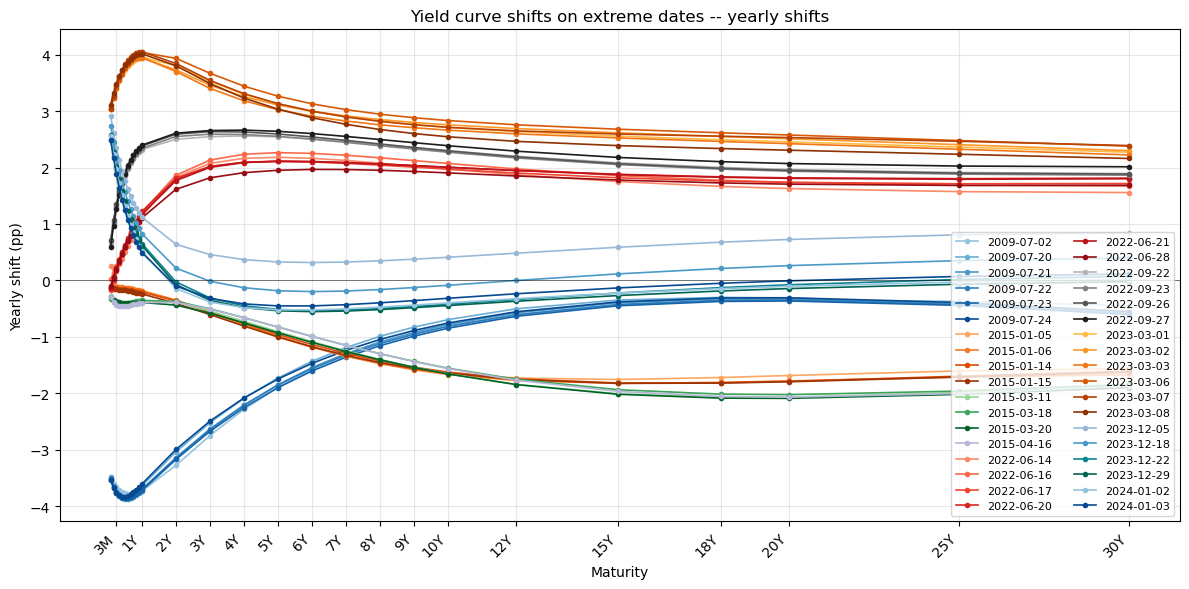

In [28]:
# ------------------------------------------------------------------
# Plot the shock scenarios.
# ------------------------------------------------------------------

_extreme_tenor_cols = [c for c in diff_extreme_df.columns if c != "Date"]
_extreme_tenor_cols_sorted = sorted(_extreme_tenor_cols, key=_tenor_to_years)
_extreme_maturities_years = [_tenor_to_years(t) for t in _extreme_tenor_cols_sorted]

# Group dates by (year, month) and assign each group its own color family
# (Blues, Oranges, ...), shading progressively darker within the group so
# dates from the same episode are visually related but still distinguishable.
_year_month = pd.to_datetime(diff_extreme_df["Date"]).dt.to_period("M")
_unique_periods = sorted(_year_month.unique())
_base_cmaps = ["Blues", "Oranges", "Greens", "Purples", "Reds", "Greys", "YlOrBr", "PuBuGn"]
_period_to_cmap = {
    p: plt.get_cmap(_base_cmaps[i % len(_base_cmaps)]) for i, p in enumerate(_unique_periods)
}
_group_sizes = _year_month.value_counts()
_group_counters = {p: 0 for p in _unique_periods}
_line_colors = []
for p in _year_month:
    idx = _group_counters[p]
    _group_counters[p] += 1
    n = _group_sizes.loc[p]
    shade = 0.4 + 0.5 * (idx / max(n - 1, 1))  # spread shades from 0.4 (light) to 0.9 (dark)
    _line_colors.append(_period_to_cmap[p](shade))

fig_extreme, ax_extreme = plt.subplots(figsize=(12, 6))
for (_, row), color in zip(diff_extreme_df.iterrows(), _line_colors):
    date_label = pd.Timestamp(row["Date"]).strftime("%Y-%m-%d")
    ax_extreme.plot(
        _extreme_maturities_years,
        row[_extreme_tenor_cols_sorted].values,
        marker="o",
        markersize=3,
        linewidth=1.2,
        color=color,
        label=date_label,
    )

ax_extreme.axhline(0, color="black", linewidth=0.7, alpha=0.5)
ax_extreme.set_xlabel("Maturity")
ax_extreme.set_ylabel(f"{PERIOD_LABELS[DIFF_PERIOD].capitalize()} shift (pp)")
ax_extreme.set_title(f"Yield curve shifts on extreme dates -- {PERIOD_LABELS[DIFF_PERIOD]} shifts")

_labelled = {"3M"} | {t for t in _extreme_tenor_cols_sorted if t.endswith("Y")}
_label_pos = [m for t, m in zip(_extreme_tenor_cols_sorted, _extreme_maturities_years) if t in _labelled]
_label_names = [t for t in _extreme_tenor_cols_sorted if t in _labelled]
ax_extreme.set_xticks(_label_pos)
ax_extreme.set_xticklabels(_label_names, rotation=45, ha="right")

ax_extreme.legend(loc="best", fontsize=8, ncol=2)
ax_extreme.grid(alpha=0.3)
fig_extreme.tight_layout()

plt.show()

###
The quantile/VaR methodology identifies 36 shock scenarios, although most of them are clustered because of the overlapping shifts.
The shifts over latter intervals are likely to be very similar to adjacent shifts over the former intervals (the 2022-06-14 shift is likely to be very similar to the 22-06-16 shift).

To reduce the number of (similar) extreme shifts a following rule is aplied: for each identified cluster of shocks (year-month basis) retain only the shock with $
\max \left( \left| PC_k \right| \right)
$. Please note that since PCs are orthogonal, a day could have a moderate PC1 and a moderate PC2 that combine into the largest overal curve move (multi tenor shift), while never being the individual maximum for either PC alone.

In [29]:
# ------------------------------------------------------------------
# Retain only max(abs(PC_k)) per date cluster.
# ------------------------------------------------------------------

extreme_dates_df["AbsScore"] = extreme_dates_df["Score"].abs()
extreme_dates_df["YearMonth"] = pd.to_datetime(extreme_dates_df["Date"]).dt.to_period("M")

idx_max_per_cluster_pc = (
    extreme_dates_df.groupby(["YearMonth", "Principal Component"])["AbsScore"].idxmax()
)
representative_rows = (
    extreme_dates_df.loc[idx_max_per_cluster_pc]
    .sort_values(["YearMonth", "Principal Component"])
    .reset_index(drop=True)
)
representative_rows

,Date,Principal Component,Score,Tail,Quantile threshold,AbsScore,YearMonth
0,2009-07-23,PC1,-13.890074,Below 0.1% quantile,-13.530140,13.890074,2009-07
1,2015-01-06,PC2,-4.564260,Below 0.1% quantile,-4.417192,4.564260,2015-01
2,2015-03-20,PC2,-4.474661,Below 0.1% quantile,-4.417192,4.474661,2015-03
3,2015-03-18,PC3,-1.475732,Below 0.1% quantile,-1.475193,1.475732,2015-03
4,2015-04-16,PC3,-1.495713,Below 0.1% quantile,-1.475193,1.495713,2015-04
5,2022-06-21,PC2,5.504536,Above 99.9% quantile,5.114915,5.504536,2022-06
6,2022-09-27,PC3,-1.578063,Below 0.1% quantile,-1.475193,1.578063,2022-09
7,2023-03-06,PC1,17.104728,Above 99.9% quantile,16.631534,17.104728,2023-03
8,2023-12-18,PC3,2.460514,Above 99.9% quantile,2.330627,2.460514,2023-12
9,2024-01-02,PC3,2.484711,Above 99.9% quantile,2.330627,2.484711,2024-01


Filtered diff_df to 10 rows out of 5333 matching 10 unique extreme date(s).


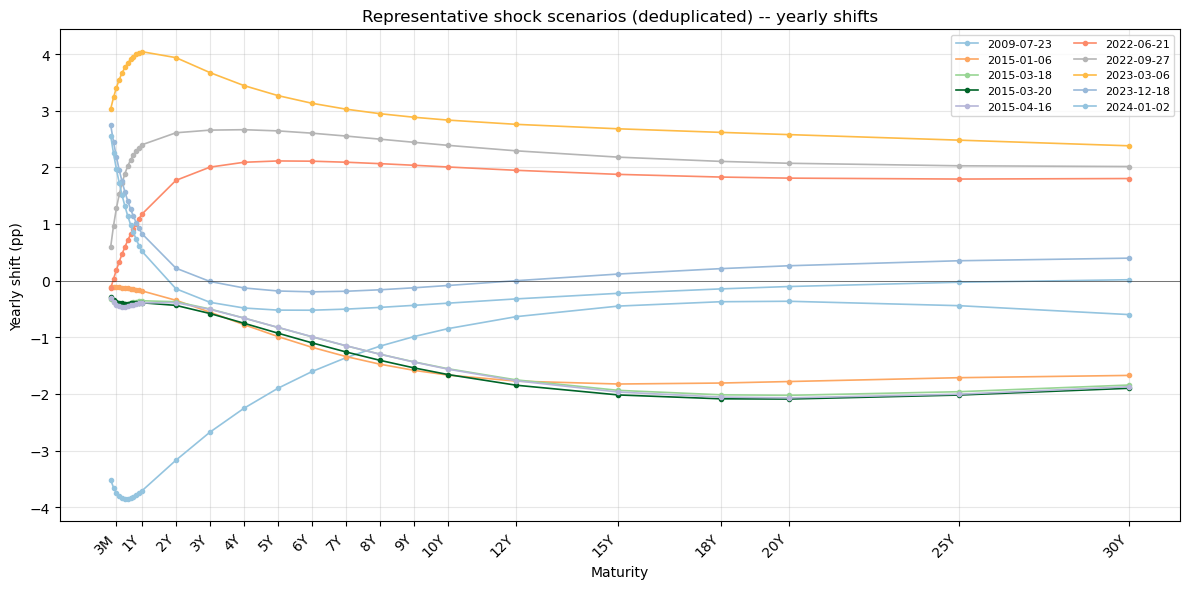

In [30]:
# ------------------------------------------------------------------
# Reduced shocks per date cluster.
# ------------------------------------------------------------------

extreme_dates_reduced = pd.to_datetime(representative_rows["Date"]).unique()
diff_extreme_reduced_df = diff_df[pd.to_datetime(diff_df["Date"]).isin(extreme_dates_reduced)].reset_index(drop=True)

print(f"Filtered diff_df to {len(diff_extreme_reduced_df)} rows out of {len(diff_df)} "
      f"matching {len(extreme_dates_reduced)} unique extreme date(s).")


_extreme_tenor_cols = [c for c in diff_extreme_reduced_df.columns if c != "Date"]
_extreme_tenor_cols_sorted = sorted(_extreme_tenor_cols, key=_tenor_to_years)
_extreme_maturities_years = [_tenor_to_years(t) for t in _extreme_tenor_cols_sorted]

# same (year, month) -> color family grouping as before
_year_month = pd.to_datetime(diff_extreme_reduced_df["Date"]).dt.to_period("M")
_unique_periods = sorted(_year_month.unique())
_period_to_cmap = {
    p: plt.get_cmap(_base_cmaps[i % len(_base_cmaps)]) for i, p in enumerate(_unique_periods)
}
_group_sizes = _year_month.value_counts()
_group_counters = {p: 0 for p in _unique_periods}
_line_colors = []
for p in _year_month:
    idx = _group_counters[p]
    _group_counters[p] += 1
    n = _group_sizes.loc[p]
    shade = 0.4 + 0.5 * (idx / max(n - 1, 1))
    _line_colors.append(_period_to_cmap[p](shade))

fig_reduced, ax_reduced = plt.subplots(figsize=(12, 6))
for (_, row), color in zip(diff_extreme_reduced_df.iterrows(), _line_colors):
    date_label = pd.Timestamp(row["Date"]).strftime("%Y-%m-%d")
    ax_reduced.plot(
        _extreme_maturities_years,
        row[_extreme_tenor_cols_sorted].values,
        marker="o",
        markersize=3,
        linewidth=1.2,
        color=color,
        label=date_label,
    )

ax_reduced.axhline(0, color="black", linewidth=0.7, alpha=0.5)
ax_reduced.set_xlabel("Maturity")
ax_reduced.set_ylabel(f"{PERIOD_LABELS[DIFF_PERIOD].capitalize()} shift (pp)")
ax_reduced.set_title(
    f"Representative shock scenarios (deduplicated) -- {PERIOD_LABELS[DIFF_PERIOD]} shifts"
)

_labelled = {"3M"} | {t for t in _extreme_tenor_cols_sorted if t.endswith("Y")}
_label_pos = [m for t, m in zip(_extreme_tenor_cols_sorted, _extreme_maturities_years) if t in _labelled]
_label_names = [t for t in _extreme_tenor_cols_sorted if t in _labelled]
ax_reduced.set_xticks(_label_pos)
ax_reduced.set_xticklabels(_label_names, rotation=45, ha="right")

ax_reduced.legend(loc="best", fontsize=8, ncol=2)
ax_reduced.grid(alpha=0.3)
fig_reduced.tight_layout()
plt.show()

## Regulatory SOT shocks
As per July 2026 there are two main legal sources of regulatory SOT shock scenarios:
- **Commission Delegated Regulation (EU) 2024/856** published in December 2023 which enforces EBA/RTS/2022/10.
  Link: https://eur-lex.europa.eu/eli/reg_del/2024/856/oj/eng
- **BCBS 578** "Recalibration of shocks in the interest rate risk in the banking book standard" published in July 2024. Link: https://www.bis.org/bcbs/publ/d578.pdf

Among the two, the BCBS adopts a more conservative approach by charging higher shocks. The present work will apply BCBS shocks.

| Shock type | EU 2024/856 | BCBS 578 |
|---|---:|---:|
| Parallel | 200 | 225 |
| Short | 250 | 350|
| Long | 100 | 200 |

There are 6 SOT scenarios:
- **parallel shock up** with the same positive interest rate shock for all maturities;
- **parallel shock down** with the same negative interest rate shock for all maturities;
- **steepener shock** with negative interest rate shocks for shorter maturities and positive interest rate shocks for longer maturities;
- **flattener shock** with positive interest rate shocks for shorter maturities and negative interest rate shocks for longer maturities;
- **short up shock** with larger positive interest rate shocks for shorter maturities to converge with the baseline for longer maturities;
- **short down shock** with larger negative interest rate shocks for shorter maturities to converge with the baseline for longer maturities.

The shock scenarios are identified according following equations:

**(a) Parallel shock for currency $c$:** A constant parallel shock up or down across all time buckets:

$$
\Delta R_{parallel,c}(t_k) = \pm \bar{R}_{parallel,c}
$$

**(b) Short rate shock for currency $c$:**

$$
\Delta R_{short,c}(t_k) = \pm \bar{R}_{short,c} \cdot e^{-\frac{t_k}{4}}
$$

where $t_k$ is the midpoint in time of the $k^{th}$ time bucket.

**(c) Long rate shock for currency $c$:**

$$
\Delta R_{long,c}(t_k) = \pm \bar{R}_{long,c} \cdot \left(1 - e^{-\frac{t_k}{4}}\right)
$$

**(d) Rotation shocks for currency $c$:**

$$
\Delta R_{steepener,c}(t_k)
=
-0.65 \cdot \left| \Delta R_{short,c}(t_k) \right|
+
0.9 \cdot \left| \Delta R_{long,c}(t_k) \right|
$$

$$
\Delta R_{flattener,c}(t_k)
=
+0.8 \cdot \left| \Delta R_{short,c}(t_k) \right|
-
0.6 \cdot \left| \Delta R_{long,c}(t_k) \right|
$$

There are 19 regulatory time buckets (EBA-RTS-2022-09, ANNEX I): https://www.eba.europa.eu/sites/default/files/document_library/Publications/Draft%20Technical%20Standards/2022/EBA-RTS-2022-09%20RTS%20on%20SA/1041755/Final%20draft%20RTS%20on%20SA.pdf

In [31]:
# ------------------------------------------------------------------
# Compute regulatory SOT shocks.
# ------------------------------------------------------------------

repricing_midpoints = {
    "ON":     1 / 360,          # 1 day
    "1D-1M":  15 / 360,         # 15 days
    "1M-3M":  60 / 360,         # 60 days
    "3M-6M":  135 / 360,        # 135 days
    "6M-9M":  225 / 360,        # 225 days
    "9M-1Y":  315 / 360,        # 315 days
    "1Y-1.5Y": 1 + 90 / 360,    # 1 year and 90 days
    "1.5Y-2Y": 1 + 270 / 360,   # 1 year and 270 days
    "2Y-3Y":   2 + 180 / 360,   # 2 years and 180 days
    "3Y-4Y":   3 + 180 / 360,   # 3 years and 180 days
    "4Y-5Y":   4 + 180 / 360,   # 4 years and 180 days
    "5Y-6Y":   5 + 180 / 360,   # 5 years and 180 days
    "6Y-7Y":   6 + 180 / 360,   # 6 years and 180 days
    "7Y-8Y":   7 + 180 / 360,   # 7 years and 180 days
    "8Y-9Y":   8 + 180 / 360,   # 8 years and 180 days
    "9Y-10Y":  9 + 180 / 360,   # 9 years and 180 days
    "10Y-15Y": 12 + 180 / 360,  # 12 years and 180 days
    "15Y-20Y": 17 + 180 / 360,  # 17 years and 180 days
    ">20Y":     25.0             # 25 years
}


# Shock parameters, expressed in basis points
parallel_shock_bps = 225
short_shock_bps = 350
long_shock_bps = 200

# repricing_midpoints is the previously defined dictionary:
# bucket label -> midpoint in years

sot_shocks_bps = pd.DataFrame({
    "Bucket": list(repricing_midpoints.keys()),
    "Midpoint_years": list(repricing_midpoints.values())
})

t = sot_shocks_bps["Midpoint_years"]

# Exponential decay term
decay_factor = np.exp(-t / 4)

# Shock magnitudes used in the scenario formulas
short_shock_magnitude = short_shock_bps * decay_factor
long_shock_magnitude = long_shock_bps * (1 - decay_factor)

# Six SOT IRRBB shock scenarios
sot_shocks_bps["Parallel up"] = parallel_shock_bps
sot_shocks_bps["Parallel down"] = -parallel_shock_bps

sot_shocks_bps["Short rate up"] = short_shock_magnitude
sot_shocks_bps["Short rate down"] = -short_shock_magnitude

sot_shocks_bps["Steepener"] = (
    -0.65 * np.abs(short_shock_magnitude)
    + 0.90 * np.abs(long_shock_magnitude)
)

sot_shocks_bps["Flattener"] = (
    0.80 * np.abs(short_shock_magnitude)
    - 0.60 * np.abs(long_shock_magnitude)
)

sot_shocks_bps.round(2)

,Bucket,Midpoint_years,Parallel up,Parallel down,Short rate up,Short rate down,Steepener,Flattener
0,ON,0.00,225,-225,349.76,-349.76,-227.22,279.72
1,1D-1M,0.04,225,-225,346.37,-346.37,-223.28,275.85
2,1M-3M,0.17,225,-225,335.72,-335.72,-210.87,263.68
3,3M-6M,0.38,225,-225,318.68,-318.68,-191.03,244.20
4,6M-9M,0.62,225,-225,299.37,-299.37,-168.55,222.14
5,9M-1Y,0.88,225,-225,281.23,-281.23,-147.44,201.41
6,1Y-1.5Y,1.25,225,-225,256.07,-256.07,-118.13,172.65
7,1.5Y-2Y,1.75,225,-225,225.98,-225.98,-83.10,138.26
8,2Y-3Y,2.50,225,-225,187.34,-187.34,-38.12,94.10
9,3Y-4Y,3.50,225,-225,145.90,-145.90,10.13,46.74


In [32]:
scenario_cols = [
    "Parallel up",
    "Parallel down",
    "Short rate up",
    "Short rate down",
    "Steepener",
    "Flattener"
]

sot_scenarios_bps = sot_shocks_bps[
    ["Bucket", "Midpoint_years"] + scenario_cols
].copy()

sot_scenarios_bps.round(2)

,Bucket,Midpoint_years,Parallel up,Parallel down,Short rate up,Short rate down,Steepener,Flattener
0,ON,0.00,225,-225,349.76,-349.76,-227.22,279.72
1,1D-1M,0.04,225,-225,346.37,-346.37,-223.28,275.85
2,1M-3M,0.17,225,-225,335.72,-335.72,-210.87,263.68
3,3M-6M,0.38,225,-225,318.68,-318.68,-191.03,244.20
4,6M-9M,0.62,225,-225,299.37,-299.37,-168.55,222.14
5,9M-1Y,0.88,225,-225,281.23,-281.23,-147.44,201.41
6,1Y-1.5Y,1.25,225,-225,256.07,-256.07,-118.13,172.65
7,1.5Y-2Y,1.75,225,-225,225.98,-225.98,-83.10,138.26
8,2Y-3Y,2.50,225,-225,187.34,-187.34,-38.12,94.10
9,3Y-4Y,3.50,225,-225,145.90,-145.90,10.13,46.74


In [33]:
sot_scenarios_perc = sot_scenarios_bps.copy()

sot_scenarios_perc[scenario_cols] = (
    sot_scenarios_perc[scenario_cols] / 100
)

sot_scenarios_perc

,Bucket,Midpoint_years,Parallel up,Parallel down,Short rate up,Short rate down,Steepener,Flattener
0,ON,0.002778,2.25,-2.25,3.497570,-3.497570,-2.272171,2.797223
1,1D-1M,0.041667,2.25,-2.25,3.463731,-3.463731,-2.232772,2.758550
2,1M-3M,0.166667,2.25,-2.25,3.357163,-3.357163,-2.108697,2.636758
3,3M-6M,0.375000,2.25,-2.25,3.186786,-3.186786,-1.910330,2.442041
4,6M-9M,0.625000,2.25,-2.25,2.993709,-2.993709,-1.685532,2.221381
5,9M-1Y,0.875000,2.25,-2.25,2.812329,-2.812329,-1.474354,2.014090
6,1Y-1.5Y,1.250000,2.25,-2.25,2.560655,-2.560655,-1.181334,1.726463
7,1.5Y-2Y,1.750000,2.25,-2.25,2.259770,-2.259770,-0.831018,1.382594
8,2Y-3Y,2.500000,2.25,-2.25,1.873415,-1.873415,-0.381190,0.941046
9,3Y-4Y,3.500000,2.25,-2.25,1.459017,-1.459017,0.101287,0.467448


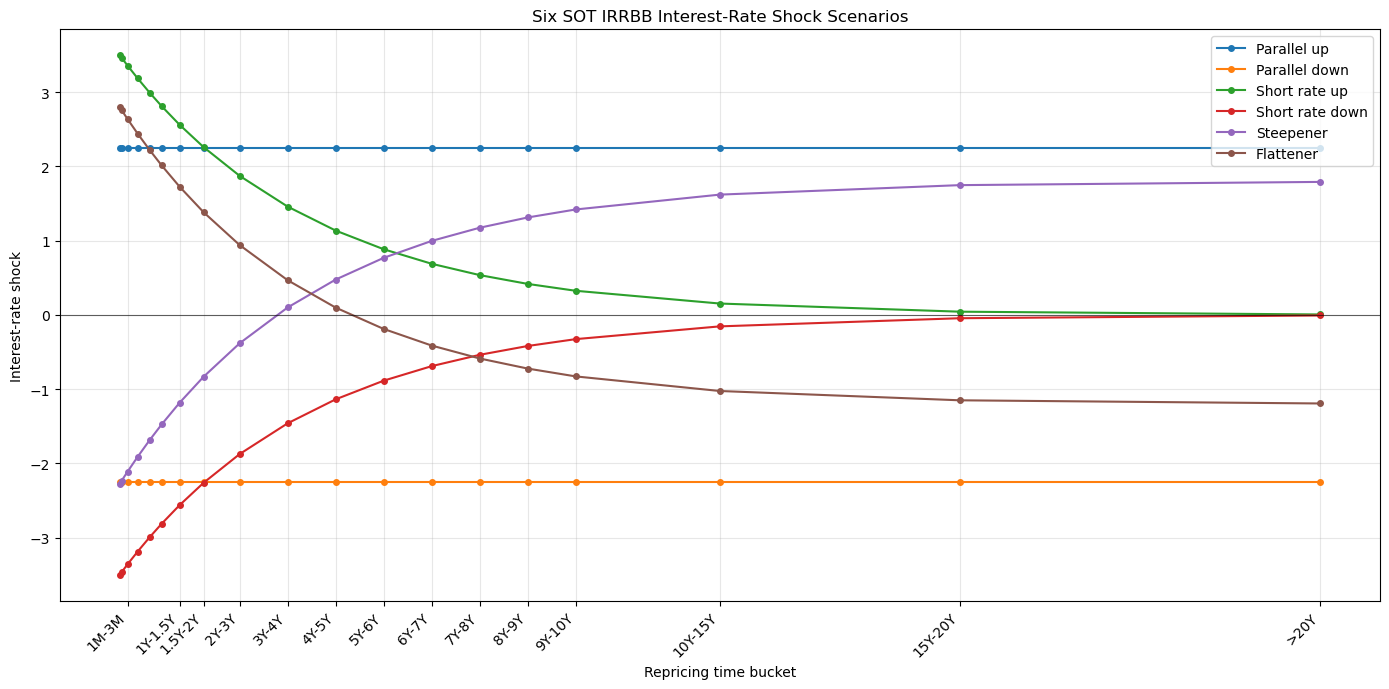

In [34]:
# ------------------------------------------------------------------
# Plot regulatory SOT shocks.
# ------------------------------------------------------------------

scenario_cols = [
    "Parallel up",
    "Parallel down",
    "Short rate up",
    "Short rate down",
    "Steepener",
    "Flattener"
]

fig, ax = plt.subplots(figsize=(14, 7))

x = sot_scenarios_perc["Midpoint_years"]

for scenario in scenario_cols:
    ax.plot(
        x,
        sot_scenarios_perc[scenario],
        linewidth=1.5,
        marker="o",
        markersize=4,
        label=scenario
    )

ax.axhline(
    0,
    color="black",
    linewidth=0.8,
    alpha=0.6
)

# Show only the 1M-3M tick below one year;
# retain all ticks corresponding to buckets above one year
tick_mask = (
    (sot_scenarios_perc["Bucket"] == "1M-3M")
    | (sot_scenarios_perc["Midpoint_years"] >= 1)
)

tick_positions = sot_scenarios_perc.loc[
    tick_mask, "Midpoint_years"
]

tick_labels = sot_scenarios_perc.loc[
    tick_mask, "Bucket"
]

ax.set_xticks(tick_positions)
ax.set_xticklabels(
    tick_labels,
    rotation=45,
    ha="right"
)

ax.set_title("Six SOT IRRBB Interest-Rate Shock Scenarios")
ax.set_xlabel("Repricing time bucket")
ax.set_ylabel("Interest-rate shock")

ax.grid(alpha=0.3)
ax.legend(loc="best")

plt.tight_layout()
plt.show()

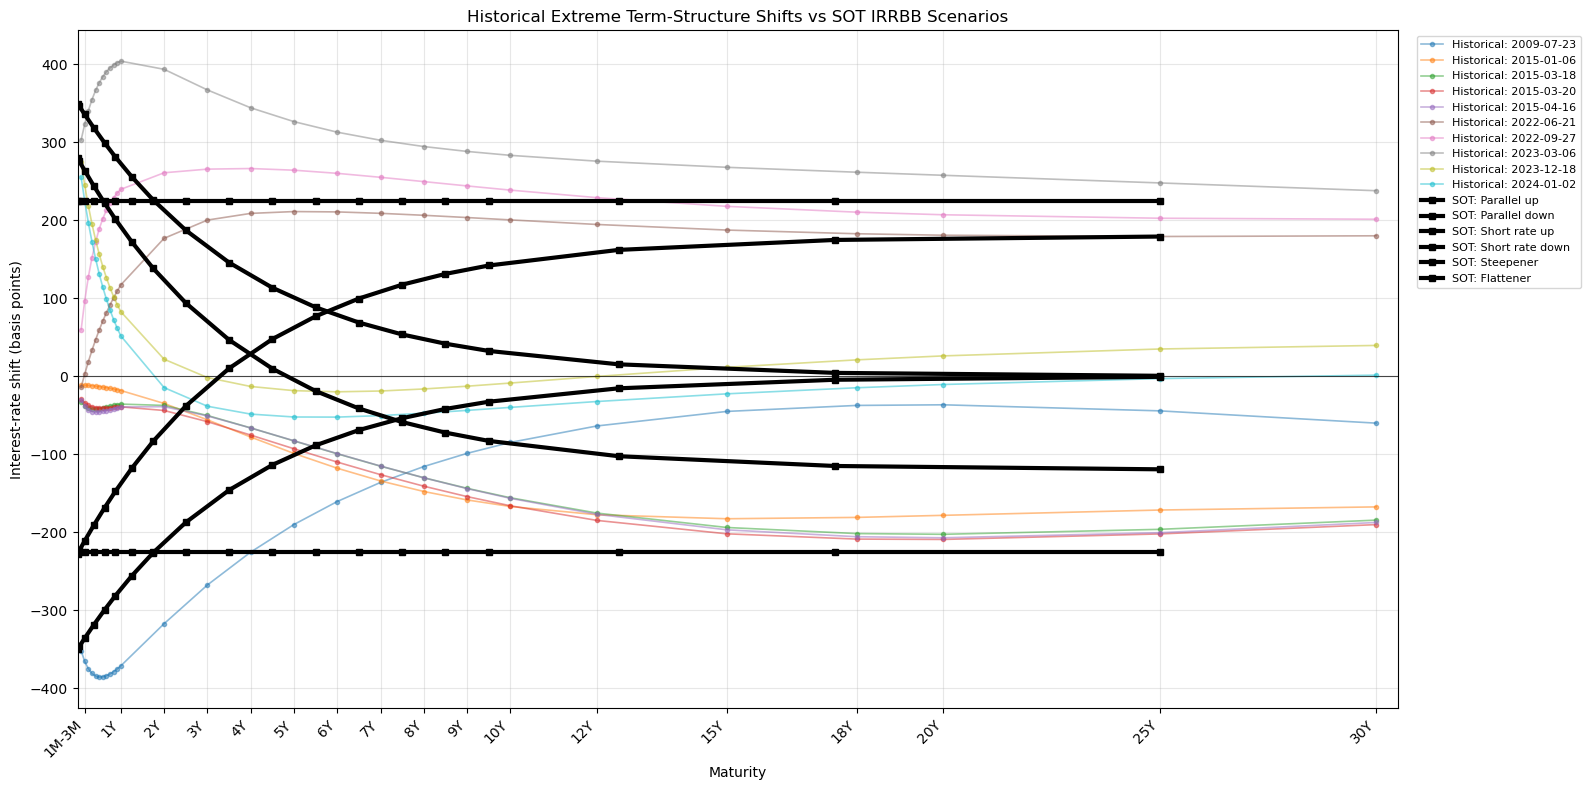

In [35]:
# ------------------------------------------------------------------
# Plot regulatory SOT shocks vs PCA shocks
# ------------------------------------------------------------------

def tenor_to_years(tenor):
    tenor = str(tenor).strip().upper()
    match = re.fullmatch(r"(\d+(?:\.\d+)?)\s*([MY])", tenor)
    if match is None:
        raise ValueError(f"Unrecognised tenor: {tenor}")
    value = float(match.group(1))
    unit = match.group(2)
    return value / 12 if unit == "M" else value

historical_tenor_cols = [
    col for col in diff_extreme_reduced_df.columns
    if col != "Date"
]

historical_maturities = np.array([
    tenor_to_years(col)
    for col in historical_tenor_cols
])

historical_extremes = diff_extreme_reduced_df.copy()
historical_extremes["Date"] = pd.to_datetime(historical_extremes["Date"])
historical_extremes[historical_tenor_cols] = (
    historical_extremes[historical_tenor_cols]
    .apply(pd.to_numeric, errors="coerce")
)

# convert percentage points to bps
historical_extremes_bps = historical_extremes.copy()
historical_extremes_bps[historical_tenor_cols] = (
    historical_extremes_bps[historical_tenor_cols] * 100
)

scenario_cols = [
    "Parallel up",
    "Parallel down",
    "Short rate up",
    "Short rate down",
    "Steepener",
    "Flattener"
]

sot_plot = sot_scenarios_bps.copy()
sot_plot["Midpoint_years"] = pd.to_numeric(
    sot_plot["Midpoint_years"], errors="coerce"
)
sot_plot = sot_plot.sort_values("Midpoint_years").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(16, 8))

# Historical scenarios
for _, row in historical_extremes_bps.iterrows():
    historical_values = row[historical_tenor_cols].to_numpy(dtype=float)

    ax.plot(
        historical_maturities,
        historical_values,
        linewidth=1.2,
        marker="o",
        markersize=3,
        alpha=0.5,
        label=f"Historical: {row['Date']:%Y-%m-%d}"
    )

# 6 SOT scenarios: thick black lines
for scenario in scenario_cols:
    ax.plot(
        sot_plot["Midpoint_years"],
        sot_plot[scenario],
        color="black",
        linewidth=3,
        linestyle="-",
        marker="s",
        markersize=4,
        label=f"SOT: {scenario}"
    )

ax.axhline(0, color="black", linewidth=0.8, alpha=0.7)

tick_positions = [
    2 / 12,
    1, 2, 3, 4, 5, 6, 7, 8, 9, 10,
    12, 15, 18, 20, 25, 30
]

tick_labels = [
    "1M-3M",
    "1Y", "2Y", "3Y", "4Y", "5Y", "6Y",
    "7Y", "8Y", "9Y", "10Y",
    "12Y", "15Y", "18Y", "20Y", "25Y", "30Y"
]

ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=45, ha="right")

ax.set_xlim(
    left=0,
    right=max(historical_maturities.max(), sot_plot["Midpoint_years"].max()) + 0.5
)

ax.set_title("Historical Extreme Term-Structure Shifts vs SOT IRRBB Scenarios")
ax.set_xlabel("Maturity")
ax.set_ylabel("Interest-rate shift (basis points)")
ax.grid(alpha=0.3)

ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.01, 1),
    fontsize=8
)

plt.tight_layout()
plt.show()

###
Comparing historical PCA shocks (yearly shifts) with the regulatory SOT scenarios it is worth to note following:
- historical PCA fails to identify pure rotational shocks (SOT Flattening/Steepening). This gap might understate the EVE like metrics under stress scenarios. In particular, a typical commercial bank's balance sheet with a positive duration gap (duration assets > duration liabilities) will be negatively affected under a SOT Steepening scenario, as short term liabilities increase in value (short rates down) and long term assets decrease in value (long rates up).
- PCA short term down (2009-07-23) and up (2023-03-06) scenarios are more severe than the comparable SOT scenarios.
- there are no pure parallel historical shifts. Although one PCA shock (2023-03-06) is significantly above the SOT parallel up scenario, there are no equivalent parallel down movements.

However, one can use $PC_k$ components independently of actual history. As mentioned before, one can observe a moderate PC1 and a moderate PC2 combine into the largest overal curve move (multi tenor shift), while individually the two PCs would not breach quantile thresholds. Given the orthognal nature of PCA, one can even project a "simulated" pure steepening/flattening term shifts by choosing extreme PC2 components while neutralising the level and curvature efffects (neutral PC1 and PC3).  

## Simulated PCA shifts

In [36]:
# ------------------------------------------------------------------
# Simulate steepener PCA shift
# ------------------------------------------------------------------

pc2_df = extreme_dates_df[
    extreme_dates_df["Principal Component"] == "PC2"
]

#choose maximum PC2 (steepener)
max_pc2 = pc2_df.loc[pc2_df["Score"].idxmax()]
max_pc2 = max_pc2["Score"]

#choose neutral PC1, PC3 
pc1_median = pca_scores_df["PC1"].median()
pc3_median = pca_scores_df["PC3"].median()

pc_vector_df = pd.DataFrame(
    [[pc1_median, max_pc2, pc3_median]],
    columns=["P1", "P2", "P3"]
)

import datetime as dt
pc_vector_df["Date"] = dt.date.today().isoformat()

pc_vector_df

,P1,P2,P3,Date
0,-0.272896,5.504536,-0.057633,2026-07-27


In [37]:
# Simulate pure steepener 
simulated_steepener_df = reconstruct_from_pca(
    pc_vector_df, pca_loadings_df, _diff_means, _diff_stds
)

In [38]:
simulated_steepener_df 

,Date,1M,2M,3M,4M,5M,6M,7M,8M,9M,...,7Y,8Y,9Y,10Y,12Y,15Y,18Y,20Y,25Y,30Y
0,2026-07-27,-1.160678,-1.101519,-1.038495,-0.973549,-0.908075,-0.84302,-0.779016,-0.716472,-0.655638,...,1.137804,1.221338,1.284889,1.333333,1.397994,1.443784,1.453829,1.448423,1.410563,1.355019


In [39]:
# ------------------------------------------------------------
# 1. Prepare and append the simulated steepener scenario
# ------------------------------------------------------------

historical_extremes_bps = historical_extremes_bps.copy()
simulated_steepener_bps = simulated_steepener_df.copy()

historical_extremes_bps["Date"] = pd.to_datetime(
    historical_extremes_bps["Date"]
)

simulated_steepener_bps["Date"] = pd.to_datetime(
    simulated_steepener_bps["Date"]
)

# Convert simulated shifts from percentage points to basis points
simulated_steepener_bps[historical_tenor_cols] = (
    simulated_steepener_bps[historical_tenor_cols]
    .apply(pd.to_numeric, errors="coerce")
    * 100
)

# Add labels to distinguish historical and simulated curves
historical_extremes_bps["Curve_type"] = "Historical extreme"
simulated_steepener_bps["Curve_type"] = "Simulated steepener"

# Ensure identical column structure
simulated_steepener_bps = simulated_steepener_bps.reindex(
    columns=["Date"] + historical_tenor_cols + ["Curve_type"]
)

historical_extremes_bps = pd.concat(
    [
        historical_extremes_bps,
        simulated_steepener_bps
    ],
    ignore_index=True
)

historical_extremes_bps

,Date,1M,2M,3M,4M,5M,6M,7M,8M,9M,...,8Y,9Y,10Y,12Y,15Y,18Y,20Y,25Y,30Y,Curve_type
0,2009-07-23,-351.883654,-365.628393,-374.986314,-380.945920,-384.280173,-385.592787,-385.354685,-383.932697,-381.612132,...,-115.650518,-98.745035,-84.722974,-63.632920,-45.001954,-37.319546,-36.505401,-44.277062,-60.023967,Historical extreme
1,2015-01-06,-11.268054,-11.420486,-11.682505,-12.049001,-12.515035,-13.075828,-13.726760,-14.463366,-15.281327,...,-147.677572,-158.516692,-166.896532,-177.491412,-182.614784,-180.892140,-178.239921,-171.440601,-167.417410,Historical extreme
2,2015-03-18,-32.596316,-37.782920,-40.594599,-41.797546,-41.946402,-41.439048,-40.557674,-39.499469,-38.399528,...,-130.044353,-143.608489,-155.723730,-175.348431,-193.818550,-201.621511,-202.561086,-196.183138,-184.382638,Historical extreme
3,2015-03-20,-28.914615,-33.885844,-37.089437,-39.025130,-40.071228,-40.512299,-40.560752,-40.373628,-40.065637,...,-140.873252,-154.219461,-165.993872,-184.758702,-201.923321,-208.700575,-209.146567,-202.084397,-190.108236,Historical extreme
4,2015-04-16,-30.178938,-38.233190,-42.875419,-45.196601,-45.979634,-45.781920,-44.996395,-43.896544,-42.669532,...,-130.107202,-143.965458,-156.448422,-176.952200,-196.801115,-205.667042,-207.015941,-200.538418,-187.389359,Historical extreme
5,2022-06-21,-13.909246,3.011181,18.700933,33.248224,46.735044,59.237586,70.826649,81.568012,91.522779,...,206.458963,203.574208,200.557684,194.705414,187.524132,182.804520,180.904316,179.272589,180.177892,Historical extreme
6,2022-09-27,59.726792,96.949540,127.334127,152.111994,172.300037,188.736866,202.113075,212.996507,221.853314,...,249.665693,244.106743,238.740590,229.091732,217.926864,210.470119,207.141818,202.696758,201.415407,Historical extreme
7,2023-03-06,303.118931,323.420437,340.479403,354.729285,366.547901,376.264452,384.165674,390.501209,395.488310,...,294.623470,288.338531,283.330921,275.850625,267.990904,261.695560,257.758088,247.964037,237.984566,Historical extreme
8,2023-12-18,274.389174,244.770256,218.610648,195.480179,175.002563,156.848710,140.730851,126.397396,113.628421,...,-16.214652,-12.663503,-8.623494,-0.156187,11.576112,21.109445,26.191025,35.033243,39.600771,Historical extreme
9,2024-01-02,255.409809,224.475020,197.012910,172.609073,150.899314,131.563585,114.320645,98.923373,85.154628,...,-47.305860,-43.671451,-39.830476,-32.294074,-22.450827,-14.658701,-10.486489,-2.931092,1.521766,Historical extreme


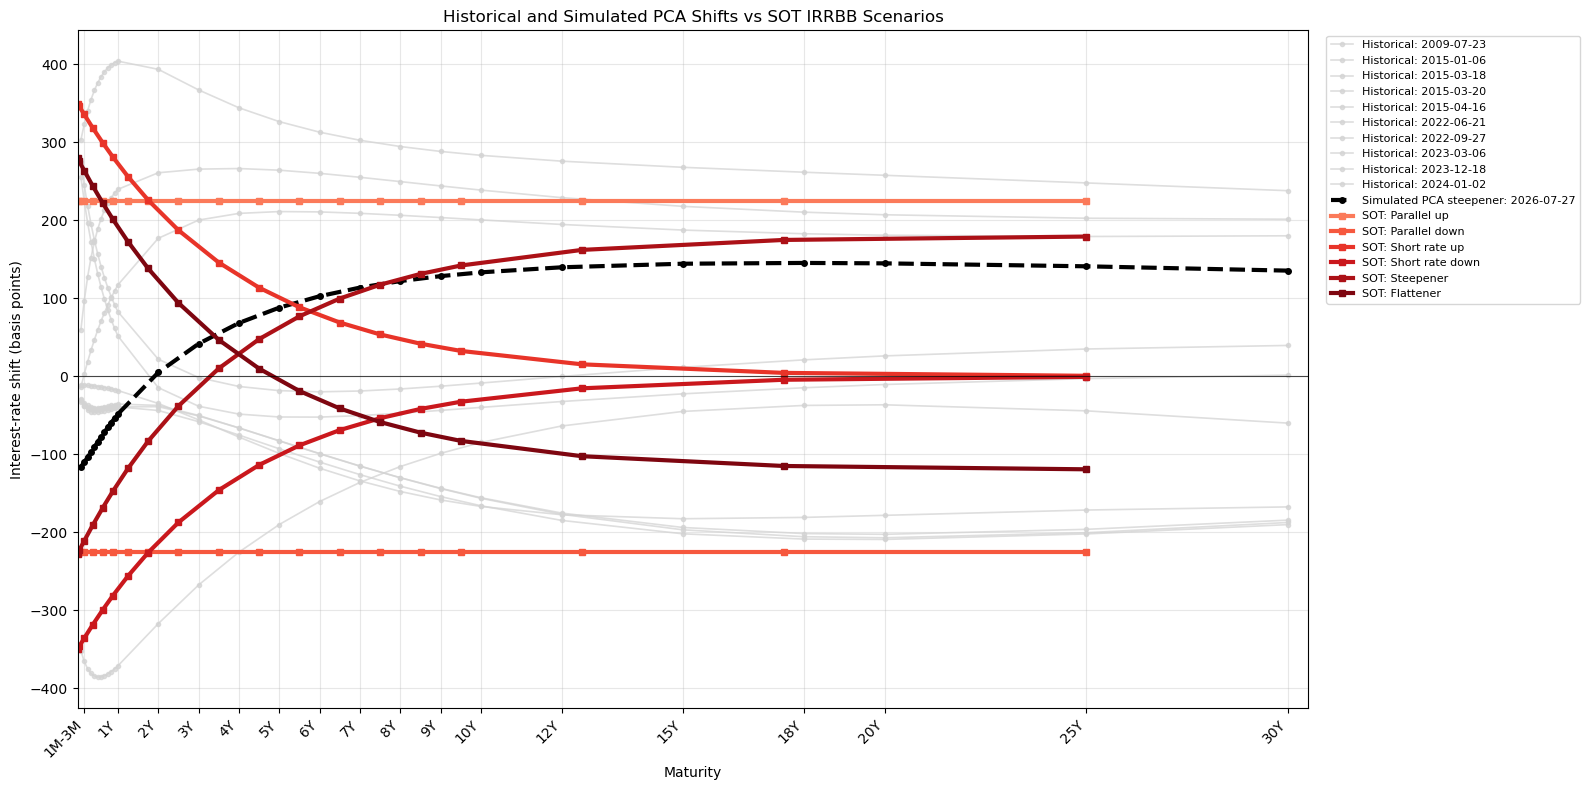

In [40]:
# ------------------------------------------------------------
# 2. Plot historical extremes, simulated steepener and SOT
# ------------------------------------------------------------

scenario_cols = [
    "Parallel up",
    "Parallel down",
    "Short rate up",
    "Short rate down",
    "Steepener",
    "Flattener"
]

fig, ax = plt.subplots(figsize=(16, 8))


# Historical extreme scenarios
historical_rows = historical_extremes_bps[
    historical_extremes_bps["Curve_type"] == "Historical extreme"
]

for _, row in historical_rows.iterrows():

    historical_values = (
        row[historical_tenor_cols]
        .to_numpy(dtype=float)
    )

    ax.plot(
        historical_maturities,
        historical_values,
        color="lightgrey",
        linewidth=1.2,
        marker="o",
        markersize=3,
        alpha=0.75,
        label=f"Historical: {row['Date']:%Y-%m-%d}"
    )


# Simulated PCA steepener
simulated_rows = historical_extremes_bps[
    historical_extremes_bps["Curve_type"] == "Simulated steepener"
]

for _, row in simulated_rows.iterrows():

    simulated_values = (
        row[historical_tenor_cols]
        .to_numpy(dtype=float)
    )

    ax.plot(
        historical_maturities,
        simulated_values,
        color="black",
        linewidth=3,
        linestyle="--",
        marker="o",
        markersize=4,
        label=f"Simulated PCA steepener: {row['Date']:%Y-%m-%d}"
    )


# Six SOT scenarios in a vibrant red scale
red_scale = plt.cm.Reds(
    np.linspace(0.45, 0.95, len(scenario_cols))
)

for colour, scenario in zip(red_scale, scenario_cols):

    ax.plot(
        sot_plot["Midpoint_years"],
        sot_plot[scenario],
        color=colour,
        linewidth=3,
        marker="s",
        markersize=4,
        label=f"SOT: {scenario}"
    )


# Zero line
ax.axhline(
    0,
    color="black",
    linewidth=0.8,
    alpha=0.7
)


# Original maturity scale, with only one tick below one year
tick_positions = [
    2 / 12,
    1, 2, 3, 4, 5, 6, 7, 8, 9, 10,
    12, 15, 18, 20, 25, 30
]

tick_labels = [
    "1M-3M",
    "1Y", "2Y", "3Y", "4Y", "5Y", "6Y",
    "7Y", "8Y", "9Y", "10Y",
    "12Y", "15Y", "18Y", "20Y", "25Y", "30Y"
]

ax.set_xticks(tick_positions)
ax.set_xticklabels(
    tick_labels,
    rotation=45,
    ha="right"
)

ax.set_xlim(
    0,
    max(
        historical_maturities.max(),
        sot_plot["Midpoint_years"].max()
    ) + 0.5
)

ax.set_title(
    "Historical and Simulated PCA Shifts vs SOT IRRBB Scenarios"
)
ax.set_xlabel("Maturity")
ax.set_ylabel("Interest-rate shift (basis points)")

ax.grid(alpha=0.3)

ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.01, 1),
    fontsize=8
)

plt.tight_layout()
plt.show()

###
The shape of the PCA simulated steepener scenario closely matches with the regulatory scenario.
Similar procedure can be applied to simulate flattener shifts (neutral PC1 and PC3, minimum PC2) or parallel shocks (VaR quantiles of PC1, and neutral PC2 and PC3).